# SKRIPSI — Analisis Sentimen & Topic Modeling Ulasan SH-RD: Protein Cream
### Notebook Terpadu — Seluruh Tahapan CRISP-DM

**Rafa Aulia Resfi — 11122136 | Sistem Informasi, Universitas Gunadarma**
Pembimbing: Dr. Tristyanti Yusnitasari, S.Kom., MMSI.

---

Notebook ini menggabungkan `Penggabungan.ipynb` dan `Dashboard.ipynb` menjadi satu alur
utuh mengikuti kerangka CRISP-DM, dan dipetakan langsung ke sub bab pada naskah skripsi.

| Bagian | Tahap CRISP-DM | Sub Bab Skripsi |
|---|---|---|
| 0 | Persiapan & bukti lingkungan | 4.1 |
| 1 | Business Understanding | 3.2 |
| 2 | Data Understanding | 3.3 / 4.1 |
| 3 | Data Preparation | 3.4 / 4.2 – 4.4 |
| 4 | Modeling | 3.5 / 4.5 |
| 5 | Evaluation | 3.6 / 4.6 |
| 6 | Deployment | 3.7 / 4.7 |

**Cara menjalankan:** urut dari atas ke bawah. Sel bertanda **[SS]** perlu di-*screenshot*
beserta kodenya sebagai bukti keaslian pada naskah.

> **Peringatan:** menjalankan ulang seluruh notebook dapat menghasilkan angka yang sedikit
> berbeda dari yang tertulis di skripsi (terutama pada LDA). Bila naskah sudah final,
> jalankan hanya sel yang keluarannya memang belum Anda punya.

---
## 0. Persiapan dan Bukti Lingkungan Eksekusi

In [ ]:
# ===== 0.1 — Instalasi pustaka =====
!pip install -q Sastrawi wordcloud gensim transformers datasets seaborn
print("Instalasi selesai.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 81.5 MB/s eta 0:00:00
Instalasi selesai.


In [ ]:
# ===== 0.2 — Mount Drive & konstanta global (dijalankan SEKALI untuk seluruh notebook) =====
import os, re, ast, json, time, random, datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')

# --- satu-satunya definisi FOLDER; seluruh sel di bawah memakai ini ---
FOLDER = '/content/drive/MyDrive/SKRIPSI/'

SHOPEE_PATH    = FOLDER + 'shopee_reviews.xlsx'
TOKOPEDIA_PATH = FOLDER + 'tokopedia_reviews.xlsx'
KOLOM = ['platform', 'username', 'rating', 'tanggal', 'content']

ORDER    = ['Positif', 'Netral', 'Negatif']
COL      = {'Positif': '#16A34A', 'Netral': '#D89A00', 'Negatif': '#D93B3B'}
label2id = {'Negatif': 0, 'Netral': 1, 'Positif': 2}
id2label = {v: k for k, v in label2id.items()}
LABELS_URUT = ['Negatif', 'Netral', 'Positif']      # sesuai id 0,1,2

SEED = 42
random.seed(SEED); np.random.seed(SEED)

pd.set_option('display.max_colwidth', 60)
pd.set_option('display.width', 200)

print('Isi folder:', os.listdir(FOLDER))

Mounted at /content/drive
Isi folder: ['shopee_reviews.xlsx', 'tokopedia_reviews.xlsx', 'reviews_GABUNGAN.csv', 'fig_data_understanding.png', 'reviews_CLEAN.csv', 'reviews_CASEFOLD.csv', 'reviews_NORM.csv', 'reviews_TOKEN.csv', 'reviews_STOPWORD.csv', 'reviews_STEMMING.csv', 'SKRIPSI_CRISP_DM_LENGKAP.ipynb']


In [ ]:
# ===== 0.3 [SS] — Bukti lingkungan eksekusi (untuk Sub Bab 4.1) =====
import sys, platform, torch, transformers, sklearn, gensim

print("Waktu eksekusi :", datetime.datetime.now().strftime("%d %B %Y, %H:%M:%S"))
print("Python         :", sys.version.split()[0])
print("Platform       :", platform.platform())
print("PyTorch        :", torch.__version__)
print("CUDA tersedia  :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU            :", torch.cuda.get_device_name(0))
print("Transformers   :", transformers.__version__)
print("scikit-learn   :", sklearn.__version__)
print("Gensim         :", gensim.__version__)
print("pandas         :", pd.__version__)

torch.manual_seed(SEED)
print("\nRandom seed    :", SEED, "(hasil dapat direproduksi)")

Waktu eksekusi : 16 August 2026, 08:26:45
Python         : 3.12.13
Platform       : Linux-6.6.122+-x86_64-with-glibc2.35
PyTorch        : 2.11.0+cu128
CUDA tersedia  : True
GPU            : Tesla T4
Transformers   : 5.13.1
scikit-learn   : 1.6.1
Gensim         : 4.4.0
pandas         : 2.2.2

Random seed    : 42 (hasil dapat direproduksi)


---
## 1. Business Understanding — Sub Bab 3.2

Tahap ini bersifat konseptual dan tidak memerlukan kode.

**Permasalahan bisnis.** Rocketindo sebagai *brand partner* produk SH-RD: Protein Cream
memerlukan pemahaman atas persepsi pelanggan dari ribuan ulasan pada Shopee dan Tokopedia,
yang tidak mungkin dibaca dan dianalisis satu per satu secara manual.

**Kriteria keberhasilan penelitian:**

| No. | Kriteria | Diuji pada |
|---|---|---|
| 1 | Model IndoBERT mampu mengklasifikasikan ulasan ke tiga kelas sentimen dengan Macro-F1 sebagai acuan utama | Bagian 5.1 |
| 2 | LDA menghasilkan topik yang koheren dan dapat diinterpretasikan pada tiap kelas sentimen | Bagian 5.2 |
| 3 | Hasil analisis mengidentifikasi aspek produk dan layanan yang perlu ditingkatkan | Bagian 4.3 |
| 4 | Dashboard monitoring berbasis Streamlit berfungsi sesuai rancangan | Bagian 5.5 |
| 5 | Data kuesioner mendukung kelayakan ulasan sebagai sumber data penelitian | Bagian 5.6 |

---
## 2. Data Understanding — Sub Bab 3.3 / 4.1

In [ ]:
# ===== 2.1 — Penggabungan data dua marketplace =====
def muat(path, platform):
    """Memuat berkas ulasan, menandai platform asal, dan menyeragamkan kolom."""
    d = pd.read_excel(path)
    d['platform'] = platform
    return d[KOLOM].copy()

shopee    = muat(SHOPEE_PATH, 'Shopee')
tokopedia = muat(TOKOPEDIA_PATH, 'Tokopedia')

gabungan = pd.concat([shopee, tokopedia], ignore_index=True)
gabungan['rating'] = pd.to_numeric(gabungan['rating'], errors='coerce')
gabungan.to_csv(FOLDER + 'reviews_GABUNGAN.csv', index=False)

print('Ulasan Shopee    :', len(shopee))
print('Ulasan Tokopedia :', len(tokopedia))
print('Total gabungan   :', len(gabungan))
display(gabungan.head())

Ulasan Shopee    : 3024
Ulasan Tokopedia : 2729
Total gabungan   : 5753


,platform,username,rating,tanggal,content
0,Shopee,n*****a,5.0,2024-12-15T14:24:15.000Z,"Tekstur:kenyal, kental dan wangi\nAroma:ada aroma yang w..."
1,Shopee,e*****6,5.0,2024-10-23T06:14:33.000Z,Tekstur:ringan\nAroma:tidak terlalu menyengat dan tidak ...
2,Shopee,n*****n,5.0,2023-07-15T11:26:21.000Z,"Tekstur:Lembut\nPerforma:Bagus\n\nIsinya penuh banyak, k..."
3,Shopee,b*****o,5.0,2024-07-13T05:38:52.000Z,Tekstur:padat dan tahan lama\nAroma:lembut tidak menyeng...
4,Shopee,d*****5,5.0,2023-01-09T05:05:42.000Z,Tekstur:krim\nPerforma:bagus\nCocok Untuk:rambut\n\nBara...


In [ ]:
# ===== 2.2 [SS] — Profil data mentah (untuk Sub Bab 4.1) =====
raw = pd.read_csv(FOLDER + 'reviews_GABUNGAN.csv')

print("Ukuran dataset mentah :", raw.shape)
print("\n--- Struktur kolom ---")
raw.info()

print("\n--- Jumlah ulasan per platform ---")
print(raw['platform'].value_counts().to_string())

print("\n--- Sebaran rating ---")
sebaran = raw['rating'].value_counts().sort_index()
for r, n in sebaran.items():
    print(f"  {int(r)} bintang : {n:>5}  ({n/len(raw)*100:5.2f}%)")

print("\n--- Rentang tanggal ulasan ---")
tgl = pd.to_datetime(raw['tanggal'], errors='coerce')
print("  Terlama :", tgl.min())
print("  Terbaru :", tgl.max())

print("\n--- Nilai kosong per kolom ---")
print(raw.isna().sum().to_string())

print("\n--- Cuplikan 5 baris pertama ---")
display(raw.head())

Ukuran dataset mentah : (5753, 5)

--- Struktur kolom ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5753 entries, 0 to 5752
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   platform  5753 non-null   object 
 1   username  5752 non-null   object 
 2   rating    5751 non-null   float64
 3   tanggal   5750 non-null   object 
 4   content   5709 non-null   object 
dtypes: float64(1), object(4)
memory usage: 224.9+ KB

--- Jumlah ulasan per platform ---
platform
Shopee       3024
Tokopedia    2729

--- Sebaran rating ---
  1 bintang :   102  ( 1.77%)
  2 bintang :    56  ( 0.97%)
  3 bintang :   165  ( 2.87%)
  4 bintang :   615  (10.69%)
  5 bintang :  4813  (83.66%)

--- Rentang tanggal ulasan ---
  Terlama : 2020-08-04 13:29:00+00:00
  Terbaru : 2026-05-17 19:59:25+00:00

--- Nilai kosong per kolom ---
platform     0
username     1
rating       2
tanggal      3
content     44

--- Cuplikan 5 baris pertama ---


,platform,username,rating,tanggal,content
0,Shopee,n*****a,5.0,2024-12-15T14:24:15.000Z,"Tekstur:kenyal, kental dan wangi\nAroma:ada aroma yang w..."
1,Shopee,e*****6,5.0,2024-10-23T06:14:33.000Z,Tekstur:ringan\nAroma:tidak terlalu menyengat dan tidak ...
2,Shopee,n*****n,5.0,2023-07-15T11:26:21.000Z,"Tekstur:Lembut\nPerforma:Bagus\n\nIsinya penuh banyak, k..."
3,Shopee,b*****o,5.0,2024-07-13T05:38:52.000Z,Tekstur:padat dan tahan lama\nAroma:lembut tidak menyeng...
4,Shopee,d*****5,5.0,2023-01-09T05:05:42.000Z,Tekstur:krim\nPerforma:bagus\nCocok Untuk:rambut\n\nBara...


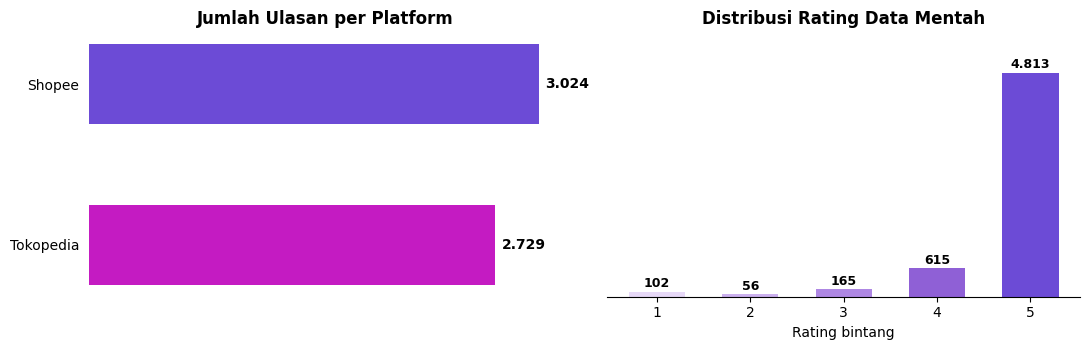

In [ ]:
# ===== 2.3 — Visualisasi kondisi awal data =====
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))

p = raw['platform'].value_counts()
b = ax[0].barh(p.index, p.values, color=['#6C4BD6', '#C41BC2'], height=0.5)
for bb, v in zip(b, p.values):
    ax[0].text(v + 40, bb.get_y() + bb.get_height()/2, f"{v:,}".replace(",", "."),
               va='center', fontweight='bold')
ax[0].set_title('Jumlah Ulasan per Platform', fontweight='bold')
ax[0].invert_yaxis()
for s in ax[0].spines.values(): s.set_visible(False)
ax[0].tick_params(bottom=False, labelbottom=False, left=False)

r = raw['rating'].value_counts().sort_index()
ramp = ['#E6D8F7', '#CBB0EE', '#AE87E3', '#8F60D6', '#6C4BD6']
b2 = ax[1].bar([str(int(i)) for i in r.index], r.values, color=ramp, width=0.6)
for bb, v in zip(b2, r.values):
    ax[1].text(bb.get_x()+bb.get_width()/2, v + max(r.values)*0.02,
               f"{v:,}".replace(",", "."), ha='center', fontweight='bold', fontsize=9)
ax[1].set_title('Distribusi Rating Data Mentah', fontweight='bold')
ax[1].set_xlabel('Rating bintang')
ax[1].set_ylim(0, max(r.values)*1.18)
for s in ['top', 'right', 'left']: ax[1].spines[s].set_visible(False)
ax[1].tick_params(left=False, labelleft=False)

plt.tight_layout()
plt.savefig(FOLDER + 'fig_data_understanding.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Data Preparation — Sub Bab 3.4 / 4.2 – 4.4

Enam tahap *pre-processing*, pelabelan berbasis *rating*, dan pembagian data.

### 3.1 Cleaning Data — Sub Bab 4.2.1

In [ ]:
# ===== 3.1 [SS] — Pembersihan data + log jumlah yang dihapus =====
df = pd.read_csv(FOLDER + 'reviews_GABUNGAN.csv')
awal = len(df)
print(f"Jumlah baris awal              : {awal}")

kosong = df['content'].isna().sum()
df = df.dropna(subset=['content'])
df['content'] = df['content'].astype(str).str.strip()
kosong += (df['content'].str.len() == 0).sum()
df = df[df['content'].str.len() > 0]
print(f"Ulasan kosong dihapus          : {kosong}")

sebelum_dup = len(df)
df = df.drop_duplicates(subset=['content']).reset_index(drop=True)
dup = sebelum_dup - len(df)
print(f"Ulasan duplikat dihapus        : {dup}")


def cleaning(teks):
    """Menghapus derau karakter pada teks ulasan."""
    teks = re.sub(r'http\S+|www\.\S+', ' ', str(teks))    # tautan
    teks = re.sub(r'_x000D_', ' ', teks)                   # artefak ekspor
    teks = re.sub(r'\b(\w{3,})2\b', r'\1 \1', teks)        # reduplikasi: bener2
    teks = re.sub(r'[^A-Za-z\s]', ' ', teks)               # emoji, angka, tanda baca
    return re.sub(r'\s+', ' ', teks).strip()


df['cleaning'] = df['content'].apply(cleaning)
df = df[df['cleaning'].str.len() > 0].reset_index(drop=True)

print(f"\nJumlah baris setelah bersih    : {len(df)}")
print(f"Total dihapus                  : {awal - len(df)}")
print("\nRincian per platform setelah pembersihan:")
print(df['platform'].value_counts().to_string())

df.to_csv(FOLDER + 'reviews_CLEAN.csv', index=False)

preview = df[['content', 'cleaning']].head(10).copy()
preview.columns = ['ulasan_asli', 'cleaning']
display(preview)

Jumlah baris awal              : 5753
Ulasan kosong dihapus          : 44
Ulasan duplikat dihapus        : 309

Jumlah baris setelah bersih    : 5373
Total dihapus                  : 380

Rincian per platform setelah pembersihan:
platform
Shopee       3016
Tokopedia    2357


,ulasan_asli,cleaning
0,"Tekstur:kenyal, kental dan wangi\nAroma:ada aroma yang w...",Tekstur kenyal kental dan wangi Aroma ada aroma yang wan...
1,Tekstur:ringan\nAroma:tidak terlalu menyengat dan tidak ...,Tekstur ringan Aroma tidak terlalu menyengat dan tidak t...
2,"Tekstur:Lembut\nPerforma:Bagus\n\nIsinya penuh banyak, k...",Tekstur Lembut Performa Bagus Isinya penuh banyak kemasa...
3,Tekstur:padat dan tahan lama\nAroma:lembut tidak menyeng...,Tekstur padat dan tahan lama Aroma lembut tidak menyenga...
4,Tekstur:krim\nPerforma:bagus\nCocok Untuk:rambut\n\nBara...,Tekstur krim Performa bagus Cocok Untuk rambut Barang sa...
5,Tekstur:halus\nPerforma:bagus\nCocok Untuk:Rambut kering...,Tekstur halus Performa bagus Cocok Untuk Rambut kering P...
6,"packing super aman, pengiriman super cepet, thankyou sel...",packing super aman pengiriman super cepet thankyou seller
7,Barang sesuai dengan pesanan packing rapih pengiriman ce...,Barang sesuai dengan pesanan packing rapih pengiriman ce...
8,Pengiriman cepat barang bagus aman packing rapih dan sesuai,Pengiriman cepat barang bagus aman packing rapih dan sesuai
9,Tekstur:cair tapi kental\nAroma:wangi\nEfek:good\n\nRepu...,Tekstur cair tapi kental Aroma wangi Efek good Repurchas...


### 3.2 Case Folding — Sub Bab 4.2.2

In [ ]:
# ===== 3.2 — Case folding =====
df = pd.read_csv(FOLDER + 'reviews_CLEAN.csv')
print('Jumlah data:', len(df))

def case_folding(teks):
    """Mengubah seluruh huruf pada teks menjadi huruf kecil."""
    return str(teks).lower()

df['case_folding'] = df['cleaning'].apply(case_folding)
df.to_csv(FOLDER + 'reviews_CASEFOLD.csv', index=False)

display(df[['cleaning', 'case_folding']].head(10))

Jumlah data: 5373


,cleaning,case_folding
0,Tekstur kenyal kental dan wangi Aroma ada aroma yang wan...,tekstur kenyal kental dan wangi aroma ada aroma yang wan...
1,Tekstur ringan Aroma tidak terlalu menyengat dan tidak t...,tekstur ringan aroma tidak terlalu menyengat dan tidak t...
2,Tekstur Lembut Performa Bagus Isinya penuh banyak kemasa...,tekstur lembut performa bagus isinya penuh banyak kemasa...
3,Tekstur padat dan tahan lama Aroma lembut tidak menyenga...,tekstur padat dan tahan lama aroma lembut tidak menyenga...
4,Tekstur krim Performa bagus Cocok Untuk rambut Barang sa...,tekstur krim performa bagus cocok untuk rambut barang sa...
5,Tekstur halus Performa bagus Cocok Untuk Rambut kering P...,tekstur halus performa bagus cocok untuk rambut kering p...
6,packing super aman pengiriman super cepet thankyou seller,packing super aman pengiriman super cepet thankyou seller
7,Barang sesuai dengan pesanan packing rapih pengiriman ce...,barang sesuai dengan pesanan packing rapih pengiriman ce...
8,Pengiriman cepat barang bagus aman packing rapih dan sesuai,pengiriman cepat barang bagus aman packing rapih dan sesuai
9,Tekstur cair tapi kental Aroma wangi Efek good Repurchas...,tekstur cair tapi kental aroma wangi efek good repurchas...


### 3.3 Normalization — Sub Bab 4.2.3

In [ ]:
# ===== 3.3 — Normalisasi kata tidak baku =====
df = pd.read_csv(FOLDER + 'reviews_CASEFOLD.csv')

KAMUS_SLANG = {
    # kata negasi
    'ga': 'tidak', 'gak': 'tidak', 'gk': 'tidak', 'g': 'tidak',
    'ngga': 'tidak', 'nggak': 'tidak', 'tdk': 'tidak',
    # singkatan umum
    'yg': 'yang', 'bgt': 'banget', 'udh': 'sudah', 'udah': 'sudah',
    'tp': 'tapi', 'tpi': 'tapi', 'jd': 'jadi', 'dgn': 'dengan',
    'krn': 'karena', 'karna': 'karena', 'utk': 'untuk', 'blm': 'belum',
    'dpt': 'dapat', 'klo': 'kalau', 'kalo': 'kalau', 'sy': 'saya',
    'ak': 'aku', 'bs': 'bisa', 'msh': 'masih', 'trs': 'terus',
    'skrg': 'sekarang', 'emg': 'memang', 'emang': 'memang',
    # ejaan tidak baku
    'pake': 'pakai', 'cepet': 'cepat', 'bener': 'benar', 'bnr': 'benar',
    'bgs': 'bagus', 'aja': 'saja', 'aj': 'saja', 'mantul': 'mantap',
    'makasih': 'terima kasih', 'makasi': 'terima kasih', 'mksh': 'terima kasih',
    # serapan bahasa Inggris
    'good': 'bagus', 'nice': 'bagus', 'soft': 'lembut', 'ok': 'oke',
    'thanks': 'terima kasih', 'thankyou': 'terima kasih',
    'recomended': 'direkomendasikan', 'recommended': 'direkomendasikan',
}


def normalization(teks):
    """Menyeragamkan kata tidak baku menjadi bentuk baku."""
    teks = re.sub(r'(.)\1{2,}', r'\1', str(teks))     # rapihhh -> rapih
    return ' '.join(KAMUS_SLANG.get(kata, kata) for kata in teks.split())


df['normalization'] = df['case_folding'].apply(normalization)
df.to_csv(FOLDER + 'reviews_NORM.csv', index=False)

berubah = (df['case_folding'] != df['normalization']).sum()
print('Jumlah entri kamus normalisasi :', len(KAMUS_SLANG))
print('Ulasan yang berubah            :', berubah, f'({berubah/len(df)*100:.1f}%)')

display(df[['case_folding', 'normalization']].head(10))

Jumlah entri kamus normalisasi : 49
Ulasan yang berubah            : 3116 (58.0%)


,case_folding,normalization
0,tekstur kenyal kental dan wangi aroma ada aroma yang wan...,tekstur kenyal kental dan wangi aroma ada aroma yang wan...
1,tekstur ringan aroma tidak terlalu menyengat dan tidak t...,tekstur ringan aroma tidak terlalu menyengat dan tidak t...
2,tekstur lembut performa bagus isinya penuh banyak kemasa...,tekstur lembut performa bagus isinya penuh banyak kemasa...
3,tekstur padat dan tahan lama aroma lembut tidak menyenga...,tekstur padat dan tahan lama aroma lembut tidak menyenga...
4,tekstur krim performa bagus cocok untuk rambut barang sa...,tekstur krim performa bagus cocok untuk rambut barang sa...
5,tekstur halus performa bagus cocok untuk rambut kering p...,tekstur halus performa bagus cocok untuk rambut kering p...
6,packing super aman pengiriman super cepet thankyou seller,packing super aman pengiriman super cepat terima kasih s...
7,barang sesuai dengan pesanan packing rapih pengiriman ce...,barang sesuai dengan pesanan packing rapih pengiriman ce...
8,pengiriman cepat barang bagus aman packing rapih dan sesuai,pengiriman cepat barang bagus aman packing rapih dan sesuai
9,tekstur cair tapi kental aroma wangi efek good repurchas...,tekstur cair tapi kental aroma wangi efek bagus repurcha...


### 3.4 Tokenization — Sub Bab 4.2.4

In [ ]:
# ===== 3.4 — Tokenisasi =====
df = pd.read_csv(FOLDER + 'reviews_NORM.csv')

def tokenization(teks):
    return str(teks).split()

df['tokenization'] = df['normalization'].apply(tokenization)
df.to_csv(FOLDER + 'reviews_TOKEN.csv', index=False)

jumlah_token = df['tokenization'].map(len)
print('Total token            :', jumlah_token.sum())
print('Rata-rata token/ulasan :', round(jumlah_token.mean(), 2))
print('Token terpanjang       :', jumlah_token.max())

display(df[['normalization', 'tokenization']].head(10))

Total token            : 104325
Rata-rata token/ulasan : 19.42
Token terpanjang       : 141


,normalization,tokenization
0,tekstur kenyal kental dan wangi aroma ada aroma yang wan...,"[tekstur, kenyal, kental, dan, wangi, aroma, ada, aroma,..."
1,tekstur ringan aroma tidak terlalu menyengat dan tidak t...,"[tekstur, ringan, aroma, tidak, terlalu, menyengat, dan,..."
2,tekstur lembut performa bagus isinya penuh banyak kemasa...,"[tekstur, lembut, performa, bagus, isinya, penuh, banyak..."
3,tekstur padat dan tahan lama aroma lembut tidak menyenga...,"[tekstur, padat, dan, tahan, lama, aroma, lembut, tidak,..."
4,tekstur krim performa bagus cocok untuk rambut barang sa...,"[tekstur, krim, performa, bagus, cocok, untuk, rambut, b..."
5,tekstur halus performa bagus cocok untuk rambut kering p...,"[tekstur, halus, performa, bagus, cocok, untuk, rambut, ..."
6,packing super aman pengiriman super cepat terima kasih s...,"[packing, super, aman, pengiriman, super, cepat, terima,..."
7,barang sesuai dengan pesanan packing rapih pengiriman ce...,"[barang, sesuai, dengan, pesanan, packing, rapih, pengir..."
8,pengiriman cepat barang bagus aman packing rapih dan sesuai,"[pengiriman, cepat, barang, bagus, aman, packing, rapih,..."
9,tekstur cair tapi kental aroma wangi efek bagus repurcha...,"[tekstur, cair, tapi, kental, aroma, wangi, efek, bagus,..."


### 3.5 Stopword Removal — Sub Bab 4.2.5

In [ ]:
# ===== 3.5 — Penghapusan stopword (negasi dikecualikan) =====
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

df = pd.read_csv(FOLDER + 'reviews_TOKEN.csv')
df['tokenization'] = df['tokenization'].apply(ast.literal_eval)

NEGASI = {'tidak', 'bukan', 'kurang', 'belum', 'jangan'}
stopword_list = [w for w in StopWordRemoverFactory().get_stop_words()
                 if w not in NEGASI]

print('Jumlah stopword setelah pengecualian negasi:', len(stopword_list))
print('Kata negasi yang sengaja dipertahankan     :', sorted(NEGASI))

def stopword_removal(tokens):
    return [kata for kata in tokens if kata not in stopword_list]

df['stopword_removal'] = df['tokenization'].apply(stopword_removal)
df.to_csv(FOLDER + 'reviews_STOPWORD.csv', index=False)

display(df[['tokenization', 'stopword_removal']].head(10))

Jumlah stopword setelah pengecualian negasi: 124
Kata negasi yang sengaja dipertahankan     : ['belum', 'bukan', 'jangan', 'kurang', 'tidak']


,tokenization,stopword_removal
0,"[tekstur, kenyal, kental, dan, wangi, aroma, ada, aroma,...","[tekstur, kenyal, kental, wangi, aroma, aroma, wangi, ti..."
1,"[tekstur, ringan, aroma, tidak, terlalu, menyengat, dan,...","[tekstur, ringan, aroma, tidak, terlalu, menyengat, tida..."
2,"[tekstur, lembut, performa, bagus, isinya, penuh, banyak...","[tekstur, lembut, performa, bagus, isinya, penuh, banyak..."
3,"[tekstur, padat, dan, tahan, lama, aroma, lembut, tidak,...","[tekstur, padat, tahan, lama, aroma, lembut, tidak, meny..."
4,"[tekstur, krim, performa, bagus, cocok, untuk, rambut, b...","[tekstur, krim, performa, bagus, cocok, rambut, barang, ..."
5,"[tekstur, halus, performa, bagus, cocok, untuk, rambut, ...","[tekstur, halus, performa, bagus, cocok, rambut, kering,..."
6,"[packing, super, aman, pengiriman, super, cepat, terima,...","[packing, super, aman, pengiriman, super, cepat, terima,..."
7,"[barang, sesuai, dengan, pesanan, packing, rapih, pengir...","[barang, sesuai, pesanan, packing, rapih, pengiriman, ce..."
8,"[pengiriman, cepat, barang, bagus, aman, packing, rapih,...","[pengiriman, cepat, barang, bagus, aman, packing, rapih,..."
9,"[tekstur, cair, tapi, kental, aroma, wangi, efek, bagus,...","[tekstur, cair, kental, aroma, wangi, efek, bagus, repur..."


### 3.6 Stemming — Sub Bab 4.2.6

In [ ]:
# ===== 3.6 — Stemming =====
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

df = pd.read_csv(FOLDER + 'reviews_STOPWORD.csv')
df['stopword_removal'] = df['stopword_removal'].apply(ast.literal_eval)

stemmer = StemmerFactory().create_stemmer()
kamus_stem = {}

def stemming(tokens):
    hasil = []
    for kata in tokens:
        if kata not in kamus_stem:
            kamus_stem[kata] = stemmer.stem(kata)
        hasil.append(kamus_stem[kata])
    return hasil

df['stemming'] = df['stopword_removal'].apply(stemming)
df.to_csv(FOLDER + 'reviews_STEMMING.csv', index=False)

print('Jumlah kata unik yang di-stem:', len(kamus_stem))
display(df[['stopword_removal', 'stemming']].head(10))

Jumlah kata unik yang di-stem: 5878


,stopword_removal,stemming
0,"[tekstur, kenyal, kental, wangi, aroma, aroma, wangi, ti...","[tekstur, kenyal, kental, wangi, aroma, aroma, wangi, ti..."
1,"[tekstur, ringan, aroma, tidak, terlalu, menyengat, tida...","[tekstur, ringan, aroma, tidak, terlalu, sengat, tidak, ..."
2,"[tekstur, lembut, performa, bagus, isinya, penuh, banyak...","[tekstur, lembut, performa, bagus, isi, penuh, banyak, k..."
3,"[tekstur, padat, tahan, lama, aroma, lembut, tidak, meny...","[tekstur, padat, tahan, lama, aroma, lembut, tidak, seng..."
4,"[tekstur, krim, performa, bagus, cocok, rambut, barang, ...","[tekstur, krim, performa, bagus, cocok, rambut, barang, ..."
5,"[tekstur, halus, performa, bagus, cocok, rambut, kering,...","[tekstur, halus, performa, bagus, cocok, rambut, kering,..."
6,"[packing, super, aman, pengiriman, super, cepat, terima,...","[packing, super, aman, kirim, super, cepat, terima, kasi..."
7,"[barang, sesuai, pesanan, packing, rapih, pengiriman, ce...","[barang, sesuai, pesan, packing, rapih, kirim, cepat, sa..."
8,"[pengiriman, cepat, barang, bagus, aman, packing, rapih,...","[kirim, cepat, barang, bagus, aman, packing, rapih, sesuai]"
9,"[tekstur, cair, kental, aroma, wangi, efek, bagus, repur...","[tekstur, cair, kental, aroma, wangi, efek, bagus, repur..."


In [ ]:
import pandas as pd

FOLDER = '/content/drive/MyDrive/SKRIPSI/'

# ===== 3.7 [SS] — Jejak satu ulasan melalui enam tahap pre-processing =====
df = pd.read_csv(FOLDER + 'reviews_STEMMING.csv')

i = 6      # ganti indeks bila ingin contoh lain

tahapan = [
    ('0. Teks asli',        'content'),
    ('1. Cleaning',         'cleaning'),
    ('2. Case Folding',     'case_folding'),
    ('3. Normalization',    'normalization'),
    ('4. Tokenization',     'tokenization'),
    ('5. Stopword Removal', 'stopword_removal'),
    ('6. Stemming',         'stemming'),
]

print("=" * 82)
print("JEJAK TRANSFORMASI SATU ULASAN MELALUI ENAM TAHAP PRE-PROCESSING")
print("=" * 82)
for label, kol in tahapan:
    print(f"{label:22}| {str(df.loc[i, kol])[:100]}")
print("=" * 82)

jejak = pd.DataFrame({'Tahap': [t[0] for t in tahapan],
                      'Hasil': [str(df.loc[i, t[1]])[:95] for t in tahapan]})
display(jejak)
jejak.to_csv(FOLDER + 'tabel_jejak_preprocessing.csv', index=False)
print("\nDisimpan: tabel_jejak_preprocessing.csv")

JEJAK TRANSFORMASI SATU ULASAN MELALUI ENAM TAHAP PRE-PROCESSING
0. Teks asli          | packing super aman, pengiriman super cepet, thankyou seller 🙂
1. Cleaning           | packing super aman pengiriman super cepet thankyou seller
2. Case Folding       | packing super aman pengiriman super cepet thankyou seller
3. Normalization      | packing super aman pengiriman super cepat terima kasih seller
4. Tokenization       | ['packing', 'super', 'aman', 'pengiriman', 'super', 'cepat', 'terima', 'kasih', 'seller']
5. Stopword Removal   | ['packing', 'super', 'aman', 'pengiriman', 'super', 'cepat', 'terima', 'kasih', 'seller']
6. Stemming           | ['packing', 'super', 'aman', 'kirim', 'super', 'cepat', 'terima', 'kasih', 'seller']


,Tahap,Hasil
0,0. Teks asli,"packing super aman, pengiriman super cepet, thankyou sel..."
1,1. Cleaning,packing super aman pengiriman super cepet thankyou seller
2,2. Case Folding,packing super aman pengiriman super cepet thankyou seller
3,3. Normalization,packing super aman pengiriman super cepat terima kasih s...
4,4. Tokenization,"['packing', 'super', 'aman', 'pengiriman', 'super', 'cep..."
5,5. Stopword Removal,"['packing', 'super', 'aman', 'pengiriman', 'super', 'cep..."
6,6. Stemming,"['packing', 'super', 'aman', 'kirim', 'super', 'cepat', ..."



Disimpan: tabel_jejak_preprocessing.csv


### 3.8 Data Labeling — Sub Bab 3.4.2 / 4.3

In [ ]:
# ===== 3.8 — Pelabelan berbasis rating =====
df = pd.read_csv(FOLDER + 'reviews_STEMMING.csv')

def pelabelan(rating):
    """Rating 1-2 = Negatif, 3 = Netral, 4-5 = Positif (Musfiroh dkk., 2024)."""
    if rating >= 4:
        return 'Positif'
    elif rating == 3:
        return 'Netral'
    return 'Negatif'

df['label'] = df['rating'].apply(pelabelan)
df.to_csv(FOLDER + 'hasil_labeling.csv', index=False)

dist  = df['label'].value_counts().reindex(ORDER)
tabel = pd.DataFrame({'Jumlah': dist, 'Persentase (%)': (dist/len(df)*100).round(2)})
tabel.loc['Total'] = [len(df), 100.0]
tabel.index.name = 'Kelas Sentimen'
print("=== DISTRIBUSI HASIL PELABELAN ===")
display(tabel)

print("=== CONTOH HASIL PELABELAN PER KELAS ===")
contoh = []
for s in ORDER:
    for _, row in df[df['label'] == s].head(2).iterrows():
        contoh.append({'Rating': int(row['rating']), 'Label': s,
                       'Ulasan': str(row['content']).strip()[:70]})
display(pd.DataFrame(contoh))

=== DISTRIBUSI HASIL PELABELAN ===


,Jumlah,Persentase (%)
Kelas Sentimen,,
Positif,5074.0,94.44
Netral,155.0,2.88
Negatif,144.0,2.68
Total,5373.0,100.00


=== CONTOH HASIL PELABELAN PER KELAS ===


,Rating,Label,Ulasan
0,5,Positif,"Tekstur:kenyal, kental dan wangi\nAroma:ada aroma yang w..."
1,5,Positif,Tekstur:ringan\nAroma:tidak terlalu menyengat dan tidak ...
2,3,Netral,"Wanginya enak, tekstur nya lembut berminyak gitu exp 202..."
3,3,Netral,Tekstur:lembut\nAroma:standar\nEfek:belum ada hasil\n\nK...
4,2,Negatif,Tekstur:sedikit berminyak\nAroma:wangi\nEfek:belum di co...
5,2,Negatif,Tekstur:terlalu oily!\nAroma:Wangi\nEfek:dirambut jadi b...


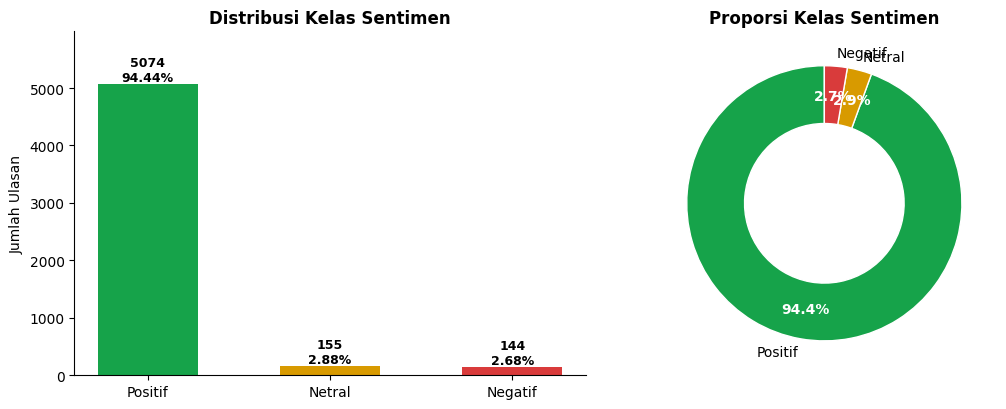

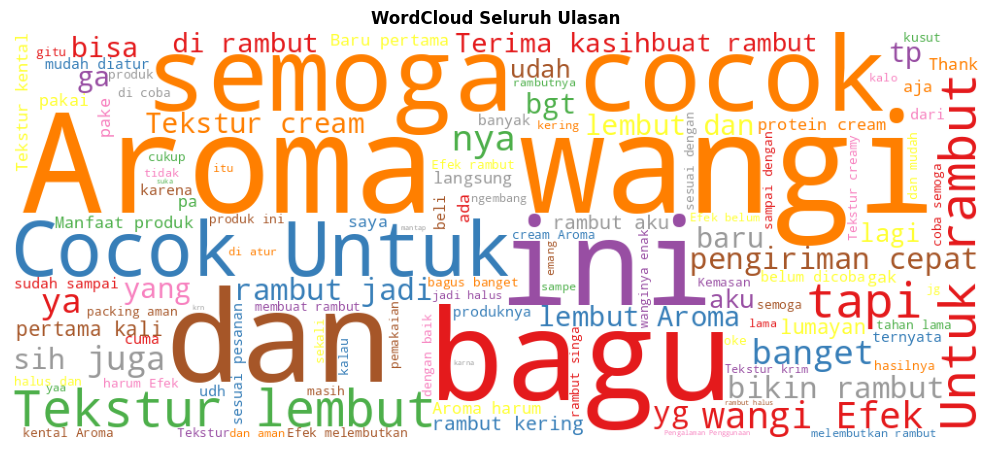

In [ ]:
# ===== 3.9 — Visualisasi distribusi label =====
from wordcloud import WordCloud

df = pd.read_csv(FOLDER + 'hasil_labeling.csv')
dist = df['label'].value_counts().reindex(ORDER)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

b = ax[0].bar(ORDER, dist.values, color=[COL[s] for s in ORDER], width=0.55)
for bb, s in zip(b, ORDER):
    ax[0].text(bb.get_x()+bb.get_width()/2, dist[s] + len(df)*0.01,
               f"{dist[s]}\n{dist[s]/len(df)*100:.2f}%", ha='center', fontsize=9, fontweight='bold')
ax[0].set_ylabel('Jumlah Ulasan'); ax[0].set_title('Distribusi Kelas Sentimen', fontweight='bold')
ax[0].set_ylim(0, dist.max()*1.18)
for s in ['top', 'right']: ax[0].spines[s].set_visible(False)

w, _, at = ax[1].pie(dist.values, labels=ORDER, colors=[COL[s] for s in ORDER],
    autopct=lambda p: f'{p:.1f}%', startangle=90, pctdistance=0.78,
    wedgeprops=dict(width=0.42, edgecolor='white'), textprops={'fontsize': 10})
for a in at: a.set_fontweight('bold'); a.set_color('white')
ax[1].set_title('Proporsi Kelas Sentimen', fontweight='bold')

plt.tight_layout()
plt.savefig(FOLDER + 'fig_distribusi_sentimen.png', dpi=150, bbox_inches='tight')
plt.show()

teks_semua = ' '.join(df['content'].astype(str))
wc = WordCloud(width=1000, height=420, background_color='white',
               colormap='Set1', max_words=120).generate(teks_semua)
plt.figure(figsize=(11, 4.6)); plt.imshow(wc); plt.axis('off')
plt.title('WordCloud Seluruh Ulasan', fontweight='bold')
plt.tight_layout(); plt.savefig(FOLDER + 'fig_wordcloud_semua.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.10 Data Splitting — Sub Bab 3.4.3 / 4.4

Hasil Pembagian Data Latih dan Data Uji


,Data Latih (80%),Data Uji (20%),Total
Kelas,,,
Positif,4059,1015,5074
Netral,124,31,155
Negatif,115,29,144
Total,4298,1075,5373



Bobot Kelas (Class Weight) — dihitung HANYA dari data latih


,Kelas,Bobot (Class Weight)
0,Negatif,12.4580
1,Netral,11.5538
2,Positif,0.3530


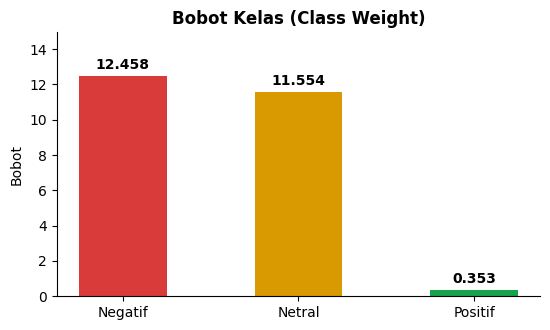

In [ ]:
# ===== 3.10 [SS] — Stratified split 80:20 + class weighting =====
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

df = pd.read_csv(FOLDER + 'hasil_labeling.csv')
df['label_id'] = df['label'].map(label2id)

train_df, test_df = train_test_split(
    df, test_size=0.20, stratify=df['label_id'], random_state=SEED)

class_weights = compute_class_weight(
    'balanced', classes=np.array([0, 1, 2]), y=train_df['label_id'].values)

tabel_split = pd.DataFrame({
    'Data Latih (80%)': train_df['label'].value_counts().reindex(ORDER),
    'Data Uji (20%)':   test_df['label'].value_counts().reindex(ORDER),
})
tabel_split['Total'] = tabel_split.sum(axis=1)
tabel_split.loc['Total'] = tabel_split.sum()
tabel_split.index.name = 'Kelas'
print("Hasil Pembagian Data Latih dan Data Uji")
display(tabel_split)

tabel_bobot = pd.DataFrame({
    'Kelas': [id2label[i] for i in [0, 1, 2]],
    'Bobot (Class Weight)': [round(class_weights[i], 4) for i in [0, 1, 2]],
})
print("\nBobot Kelas (Class Weight) — dihitung HANYA dari data latih")
display(tabel_bobot)

train_df.to_csv(FOLDER + 'data_train.csv', index=False)
test_df.to_csv(FOLDER + 'data_test.csv', index=False)
np.save(FOLDER + 'class_weights.npy', class_weights)

plt.figure(figsize=(5.6, 3.4))
b = plt.bar(tabel_bobot['Kelas'], tabel_bobot['Bobot (Class Weight)'],
            color=[COL[k] for k in tabel_bobot['Kelas']], width=0.5)
for bb, v in zip(b, tabel_bobot['Bobot (Class Weight)']):
    plt.text(bb.get_x()+bb.get_width()/2, v + 0.4, f"{v:.3f}", ha='center', fontweight='bold')
plt.ylabel('Bobot'); plt.title('Bobot Kelas (Class Weight)', fontweight='bold')
plt.ylim(0, max(tabel_bobot['Bobot (Class Weight)'])*1.2)
for s in ['top', 'right']: plt.gca().spines[s].set_visible(False)
plt.tight_layout(); plt.savefig(FOLDER + 'fig_class_weight.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Modeling — Sub Bab 3.5 / 4.5

Dua metode dijalankan berurutan: IndoBERT untuk klasifikasi sentimen, lalu LDA
pada tiap kelas hasil klasifikasi tersebut.

### 4.1 Analisis Sentimen dengan IndoBERT — Sub Bab 4.5.1

In [ ]:
# ===== 4.1a — Persiapan dataset & model =====
import torch
from torch import nn
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer)
from datasets import Dataset
from sklearn.metrics import f1_score, accuracy_score

MODEL = 'indobenchmark/indobert-base-p1'

train_df = pd.read_csv(FOLDER + 'data_train.csv')
test_df  = pd.read_csv(FOLDER + 'data_test.csv')
class_weights = np.load(FOLDER + 'class_weights.npy')

# Masukan IndoBERT = hasil NORMALIZATION (konteks kalimat terjaga, TANPA stemming)
TEXT = 'normalization' if 'normalization' in train_df.columns else 'content'
print("Kolom teks yang dipakai IndoBERT:", TEXT)

for d in (train_df, test_df):
    d[TEXT] = d[TEXT].astype(str)
    d['labels'] = d['label'].map(label2id)

tokenizer = AutoTokenizer.from_pretrained(MODEL)
def tok(b): return tokenizer(b[TEXT], truncation=True, max_length=128)

ds_train = Dataset.from_pandas(train_df[[TEXT, 'labels']].reset_index(drop=True)).map(tok, batched=True)
ds_test  = Dataset.from_pandas(test_df[[TEXT, 'labels']].reset_index(drop=True)).map(tok, batched=True)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL, num_labels=len(label2id), id2label=id2label, label2id=label2id)

print("Jumlah label pada model :", model.config.num_labels)
print("Data latih / data uji   :", len(ds_train), "/", len(ds_test))

Kolom teks yang dipakai IndoBERT: normalization


Map:   0%|          | 0/4298 [00:00<?, ? examples/s]

Map:   0%|          | 0/1075 [00:00<?, ? examples/s]

[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `5`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Jumlah label pada model : 3
Data latih / data uji   : 4298 / 1075


In [ ]:
# ===== 4.1b — Konfigurasi pelatihan dengan weighted cross-entropy =====
cw = torch.tensor(class_weights, dtype=torch.float)

class WeightedTrainer(Trainer):
    """Trainer dengan fungsi loss berbobot untuk menangani ketidakseimbangan kelas."""
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop('labels')
        outputs = model(**inputs)
        loss = nn.CrossEntropyLoss(weight=cw.to(outputs.logits.device))(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

def compute_metrics(p):
    preds = p.predictions.argmax(-1)
    return {'accuracy': accuracy_score(p.label_ids, preds),
            'macro_f1': f1_score(p.label_ids, preds, average='macro')}

args = TrainingArguments(
    output_dir=FOLDER + 'indobert_ckpt',
    num_train_epochs=6,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    fp16=torch.cuda.is_available(),
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='macro_f1',
    greater_is_better=True,
    logging_steps=50,
    seed=SEED,
    report_to='none',
)

trainer = WeightedTrainer(
    model=model, args=args,
    train_dataset=ds_train, eval_dataset=ds_test,
    processing_class=tokenizer, compute_metrics=compute_metrics,
)
print("Konfigurasi pelatihan siap.")

Konfigurasi pelatihan siap.


In [ ]:
# ===== 4.1c [SS] — Proses fine-tuning (SCREENSHOT SELURUH SEL INI) =====
mulai = time.time()
hasil_latih = trainer.train()
durasi = time.time() - mulai

print(f"\nDurasi pelatihan : {durasi/60:.2f} menit")
print(f"Perangkat        : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print(f"Jumlah epoch     : {int(args.num_train_epochs)}")
print(f"Total langkah    : {hasil_latih.global_step}")

riwayat = pd.DataFrame([h for h in trainer.state.log_history if 'eval_macro_f1' in h])
riwayat = riwayat[['epoch', 'eval_loss', 'eval_accuracy', 'eval_macro_f1']].round(4)
riwayat.columns = ['Epoch', 'Validation Loss', 'Accuracy', 'Macro-F1']
riwayat['Epoch'] = riwayat['Epoch'].astype(int)

print("\n=== RIWAYAT PELATIHAN (dari trainer.state.log_history) ===")
display(riwayat)
riwayat.to_csv(FOLDER + 'tabel_riwayat_epoch.csv', index=False)

best = riwayat.loc[riwayat['Macro-F1'].idxmax()]
print(f"\nEpoch dengan Macro-F1 tertinggi : {int(best['Epoch'])} (Macro-F1 = {best['Macro-F1']:.4f})")
print("Checkpoint terbaik dimuat otomatis karena load_best_model_at_end=True")

trainer.save_model(FOLDER + 'indobert_final')
tokenizer.save_pretrained(FOLDER + 'indobert_final')
print("Model final disimpan di:", FOLDER + 'indobert_final')

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.927724,1.611957,0.956279,0.525698
2,0.681706,1.122239,0.936744,0.586330
3,0.688240,1.730035,0.949767,0.572017
4,0.210700,1.845512,0.944186,0.600294
5,0.190440,2.153538,0.946977,0.592764
6,0.003847,2.172165,0.947907,0.602072


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...


Durasi pelatihan : 3.88 menit
Perangkat        : Tesla T4
Jumlah epoch     : 6
Total langkah    : 1614

=== RIWAYAT PELATIHAN (dari trainer.state.log_history) ===


,Epoch,Validation Loss,Accuracy,Macro-F1
0,1,1.6120,0.9563,0.5257
1,2,1.1222,0.9367,0.5863
2,3,1.7300,0.9498,0.5720
3,4,1.8455,0.9442,0.6003
4,5,2.1535,0.9470,0.5928
5,6,2.1722,0.9479,0.6021



Epoch dengan Macro-F1 tertinggi : 6 (Macro-F1 = 0.6021)
Checkpoint terbaik dimuat otomatis karena load_best_model_at_end=True


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model final disimpan di: /content/drive/MyDrive/SKRIPSI/indobert_final


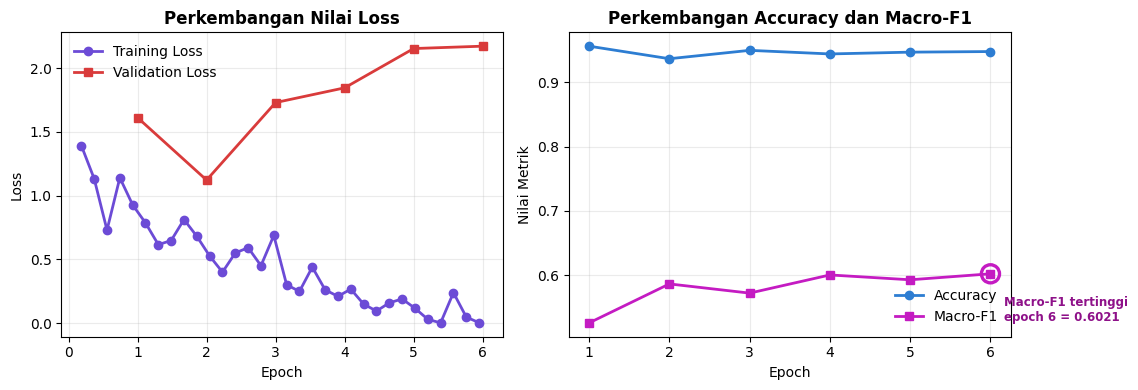

In [ ]:
# ===== 4.1d — Grafik training history =====
logs = trainer.state.log_history
ep_tr, tr_loss = [], []
ep_ev, ev_loss, ev_acc, ev_f1 = [], [], [], []

for lg in logs:
    if 'loss' in lg and 'eval_loss' not in lg and 'epoch' in lg:
        ep_tr.append(lg['epoch']); tr_loss.append(lg['loss'])
    if 'eval_loss' in lg:
        ep_ev.append(lg['epoch']); ev_loss.append(lg['eval_loss'])
        ev_acc.append(lg.get('eval_accuracy')); ev_f1.append(lg.get('eval_macro_f1'))

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4))

ax[0].plot(ep_tr, tr_loss, 'o-', color='#6C4BD6', label='Training Loss', lw=2)
ax[0].plot(ep_ev, ev_loss, 's-', color='#D93B3B', label='Validation Loss', lw=2)
ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('Loss')
ax[0].set_title('Perkembangan Nilai Loss', fontweight='bold')
ax[0].legend(frameon=False); ax[0].grid(alpha=0.25)

ax[1].plot(ep_ev, ev_acc, 'o-', color='#2D7DD2', label='Accuracy', lw=2)
ax[1].plot(ep_ev, ev_f1,  's-', color='#C41BC2', label='Macro-F1', lw=2)
k_best = ep_ev[int(np.argmax(ev_f1))]
ax[1].scatter([k_best], [max(ev_f1)], s=170, facecolors='none',
              edgecolors='#C41BC2', lw=2.4, zorder=5)
ax[1].annotate(f'Macro-F1 tertinggi\nepoch {int(k_best)} = {max(ev_f1):.4f}',
               xy=(k_best, max(ev_f1)), xytext=(10, -34), textcoords='offset points',
               fontsize=8.5, color='#8E1189', fontweight='bold')
ax[1].set_xlabel('Epoch'); ax[1].set_ylabel('Nilai Metrik')
ax[1].set_title('Perkembangan Accuracy dan Macro-F1', fontweight='bold')
ax[1].legend(frameon=False); ax[1].grid(alpha=0.25)

plt.tight_layout()
plt.savefig(FOLDER + 'fig_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ===== 4.1e — Klasifikasi seluruh ulasan dengan model final =====
df_all = pd.read_csv(FOLDER + 'hasil_labeling.csv')
df_all[TEXT] = df_all[TEXT].astype(str)
ds_all = Dataset.from_pandas(df_all[[TEXT]].reset_index(drop=True)).map(tok, batched=True)

pred = trainer.predict(ds_all).predictions.argmax(-1)
df_all['sentimen_pred'] = [id2label[i] for i in pred]
df_all.to_csv(FOLDER + 'hasil_prediksi.csv', index=False)

banding = pd.DataFrame({
    'Label (berbasis rating)': df_all['label'].value_counts().reindex(ORDER),
    'Prediksi (IndoBERT)':     df_all['sentimen_pred'].value_counts().reindex(ORDER),
})
banding['Selisih'] = banding['Prediksi (IndoBERT)'] - banding['Label (berbasis rating)']
banding.index.name = 'Kelas'
print("Perbandingan distribusi label dan hasil prediksi pada SELURUH dataset")
display(banding)
print("\nCatatan: jumlah dokumen pada tahap LDA mengacu pada kolom PREDIKSI, bukan label rating.")
print("Disimpan: hasil_prediksi.csv")

Map:   0%|          | 0/5373 [00:00<?, ? examples/s]

Perbandingan distribusi label dan hasil prediksi pada SELURUH dataset


,Label (berbasis rating),Prediksi (IndoBERT),Selisih
Kelas,,,
Positif,5074,5084,10
Netral,155,152,-3
Negatif,144,137,-7



Catatan: jumlah dokumen pada tahap LDA mengacu pada kolom PREDIKSI, bukan label rating.
Disimpan: hasil_prediksi.csv


### 4.2 Topic Modeling dengan LDA — Sub Bab 4.5.2

In [ ]:
# ===== 4.2a — Fungsi LDA per kelas sentimen (sweep k, pilih coherence tertinggi) =====
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel

def jalankan_lda(df, kelas, k_range=range(2, 9), seed=SEED):
    """LDA untuk satu kelas sentimen. Mengembalikan dict berisi model, k optimal,
    nilai coherence untuk seluruh k, dictionary, corpus, dan dokumen."""
    subset = df[df['sentimen_pred'] == kelas].copy()
    docs = [ast.literal_eval(x) if isinstance(x, str) else x for x in subset['stemming']]
    docs = [d for d in docs if d]
    if len(docs) < 5:
        print(f"Kelas {kelas}: dokumen terlalu sedikit ({len(docs)}). Dilewati.")
        return None

    dct = corpora.Dictionary(docs)
    dct.filter_extremes(no_below=2, no_above=0.5)
    corpus = [dct.doc2bow(d) for d in docs]
    corpus = [c for c in corpus if c]

    print(f"\n{'='*64}\nLDA — Kelas {kelas}")
    print(f"Dokumen: {len(corpus)} | Kata unik: {len(dct)}\n{'='*64}")

    skor, model_k = {}, {}
    for k in k_range:
        m = LdaModel(corpus, id2word=dct, num_topics=k, random_state=seed,
                     passes=20, iterations=300, alpha='auto', eta='auto')
        cv = CoherenceModel(model=m, texts=docs, dictionary=dct,
                            coherence='c_v').get_coherence()
        skor[k] = cv; model_k[k] = m
        print(f"  k={k}: c_v = {cv:.4f}")

    k_opt = max(skor, key=skor.get)
    print(f"  >> k optimal = {k_opt} (c_v = {skor[k_opt]:.4f})")
    return {'kelas': kelas, 'k_opt': k_opt, 'coherence': skor,
            'cv_opt': skor[k_opt], 'lda': model_k[k_opt],
            'dict': dct, 'corpus': corpus, 'docs': docs, 'n_docs': len(corpus)}


df_pred = pd.read_csv(FOLDER + 'hasil_prediksi.csv')
HASIL_LDA = {}
for kelas in ORDER:
    r = jalankan_lda(df_pred, kelas)
    if r: HASIL_LDA[kelas] = r

ringkas = pd.DataFrame([{'Kelas': k, 'Jumlah Dokumen': v['n_docs'],
                         'k Optimal': v['k_opt'], 'Coherence (c_v)': round(v['cv_opt'], 4)}
                        for k, v in HASIL_LDA.items()])
print("\n=== RINGKASAN JUMLAH TOPIK OPTIMAL DAN COHERENCE PER KELAS ===")
display(ringkas)
ringkas.to_csv(FOLDER + 'tabel_koptimal_coherence.csv', index=False)


LDA — Kelas Positif
Dokumen: 5065 | Kata unik: 2099


  k=2: c_v = 0.5267


  k=3: c_v = 0.5582
  k=4: c_v = 0.5608
  k=5: c_v = 0.5433
  k=6: c_v = 0.5424
  k=7: c_v = 0.5033
  k=8: c_v = 0.5131
  >> k optimal = 4 (c_v = 0.5608)

LDA — Kelas Netral
Dokumen: 152 | Kata unik: 273
  k=2: c_v = 0.4212
  k=3: c_v = 0.3515
  k=4: c_v = 0.3929
  k=5: c_v = 0.4163
  k=6: c_v = 0.3681
  k=7: c_v = 0.3973
  k=8: c_v = 0.3865
  >> k optimal = 2 (c_v = 0.4212)

LDA — Kelas Negatif
Dokumen: 136 | Kata unik: 294
  k=2: c_v = 0.2903
  k=3: c_v = 0.3115
  k=4: c_v = 0.2956
  k=5: c_v = 0.3427
  k=6: c_v = 0.3707
  k=7: c_v = 0.4255
  k=8: c_v = 0.3329
  >> k optimal = 7 (c_v = 0.4255)

=== RINGKASAN JUMLAH TOPIK OPTIMAL DAN COHERENCE PER KELAS ===


,Kelas,Jumlah Dokumen,k Optimal,Coherence (c_v)
0,Positif,5065,4,0.5608
1,Netral,152,2,0.4212
2,Negatif,136,7,0.4255


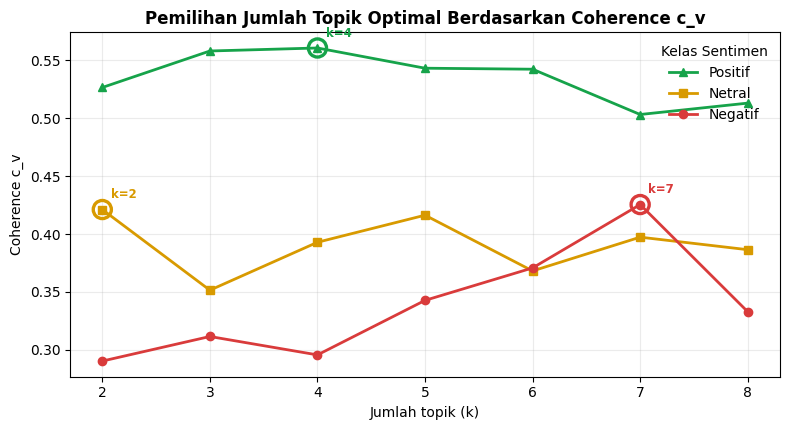

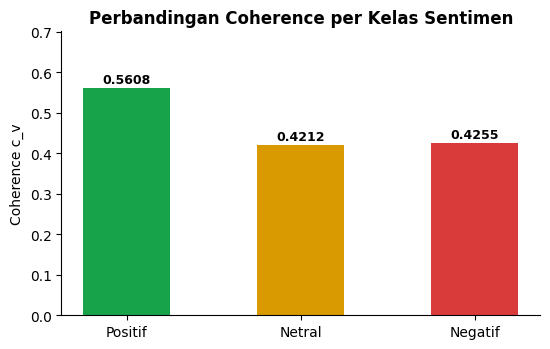

In [ ]:
# ===== 4.2b — Grafik coherence vs jumlah topik (dihitung, bukan ditulis manual) =====
plt.figure(figsize=(8, 4.4))
marker = {'Positif': '^', 'Netral': 's', 'Negatif': 'o'}

for kelas, v in HASIL_LDA.items():
    ks  = sorted(v['coherence'])
    cvs = [v['coherence'][k] for k in ks]
    plt.plot(ks, cvs, marker[kelas] + '-', color=COL[kelas], label=kelas, lw=2)
    plt.scatter([v['k_opt']], [v['cv_opt']], s=170, facecolors='none',
                edgecolors=COL[kelas], lw=2.4, zorder=5)
    plt.annotate(f"k={v['k_opt']}", xy=(v['k_opt'], v['cv_opt']),
                 xytext=(6, 8), textcoords='offset points',
                 fontsize=8.5, fontweight='bold', color=COL[kelas])

plt.xlabel('Jumlah topik (k)'); plt.ylabel('Coherence c_v')
plt.title('Pemilihan Jumlah Topik Optimal Berdasarkan Coherence c_v', fontweight='bold')
plt.legend(frameon=False, title='Kelas Sentimen'); plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(FOLDER + 'fig_coherence_vs_k.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(5.6, 3.6))
b = plt.bar(list(HASIL_LDA), [HASIL_LDA[k]['cv_opt'] for k in HASIL_LDA],
            color=[COL[k] for k in HASIL_LDA], width=0.5)
for bb, k in zip(b, HASIL_LDA):
    plt.text(bb.get_x()+bb.get_width()/2, HASIL_LDA[k]['cv_opt'] + 0.012,
             f"{HASIL_LDA[k]['cv_opt']:.4f}", ha='center', fontweight='bold', fontsize=9)
plt.ylabel('Coherence c_v'); plt.title('Perbandingan Coherence per Kelas Sentimen', fontweight='bold')
plt.ylim(0, max(HASIL_LDA[k]['cv_opt'] for k in HASIL_LDA)*1.25)
for s in ['top', 'right']: plt.gca().spines[s].set_visible(False)
plt.tight_layout(); plt.savefig(FOLDER + 'fig_coherence_perkelas.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ===== 4.2c [SS] — Keluaran mentah topik LDA beserta bobot kata =====
baris = []
for kelas, v in HASIL_LDA.items():
    print("=" * 78)
    print(f"TOPIK KELAS {kelas.upper()}  |  k = {v['k_opt']}  |  c_v = {v['cv_opt']:.4f}")
    print("=" * 78)
    for idx, topik in v['lda'].print_topics(num_words=8):
        print(f"Topik {idx+1}: {topik}\n")
        kata = [t.split('*')[1].strip().strip('"') for t in topik.split(' + ')]
        baris.append({'Kelas': kelas, 'Topik': idx + 1,
                      'Kata Kunci Dominan': ', '.join(kata)})

tabel_topik = pd.DataFrame(baris)
print("=== TABEL KATA KUNCI PER TOPIK (untuk Tabel 4.4 - 4.6) ===")
display(tabel_topik)
tabel_topik.to_csv(FOLDER + 'tabel_topik_lda.csv', index=False)

TOPIK KELAS POSITIF  |  k = 4  |  c_v = 0.5608
Topik 1: 0.026*"beli" + 0.024*"pakai" + 0.017*"baru" + 0.016*"banget" + 0.015*"tidak" + 0.015*"coba" + 0.014*"kecil" + 0.014*"bagus"

Topik 2: 0.063*"tekstur" + 0.053*"aroma" + 0.051*"wangi" + 0.044*"lembut" + 0.042*"efek" + 0.031*"cocok" + 0.027*"bagus" + 0.024*"tidak"

Topik 3: 0.053*"banget" + 0.036*"tidak" + 0.030*"jadi" + 0.027*"aku" + 0.026*"bagus" + 0.025*"bikin" + 0.023*"lembut" + 0.021*"pakai"

Topik 4: 0.047*"terima" + 0.045*"kirim" + 0.043*"cepat" + 0.042*"barang" + 0.042*"kasih" + 0.038*"sesuai" + 0.036*"aman" + 0.027*"baik"

TOPIK KELAS NETRAL  |  k = 2  |  c_v = 0.4212
Topik 1: 0.032*"tidak" + 0.021*"beli" + 0.021*"ml" + 0.018*"aku" + 0.018*"bagus" + 0.017*"produk" + 0.017*"minyak" + 0.016*"coba"

Topik 2: 0.055*"tidak" + 0.049*"rambut" + 0.025*"pakai" + 0.025*"bagus" + 0.017*"efek" + 0.017*"harga" + 0.016*"nya" + 0.016*"belum"

TOPIK KELAS NEGATIF  |  k = 7  |  c_v = 0.4255
Topik 1: 0.034*"kirim" + 0.031*"beli" + 0.026*"peca

,Kelas,Topik,Kata Kunci Dominan
0,Positif,1,"beli, pakai, baru, banget, tidak, coba, kecil, bagus"
1,Positif,2,"tekstur, aroma, wangi, lembut, efek, cocok, bagus, tidak"
2,Positif,3,"banget, tidak, jadi, aku, bagus, bikin, lembut, pakai"
3,Positif,4,"terima, kirim, cepat, barang, kasih, sesuai, aman, baik"
4,Netral,1,"tidak, beli, ml, aku, bagus, produk, minyak, coba"
5,Netral,2,"tidak, rambut, pakai, bagus, efek, harga, nya, belum"
6,Negatif,1,"kirim, beli, pecah, pcs, kemas, rusak, toko, kilap"
7,Negatif,2,"sesuai, ngembang, rambut, aku, gambar, kok, iklan, gitu"
8,Negatif,3,"kirim, nya, produk, kecil, barang, shampoo, lebih, sesuai"
9,Negatif,4,"rambut, nya, pakai, malah, banget, mahal, rontok, sama"


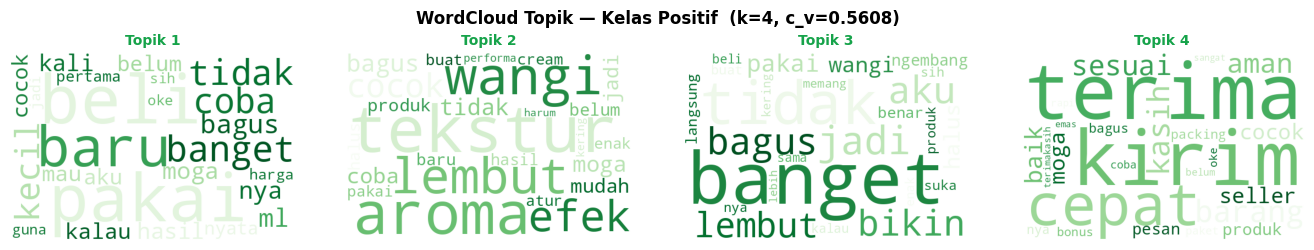

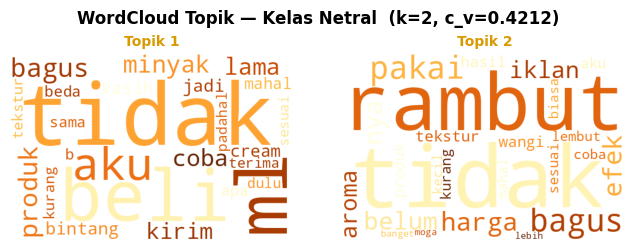

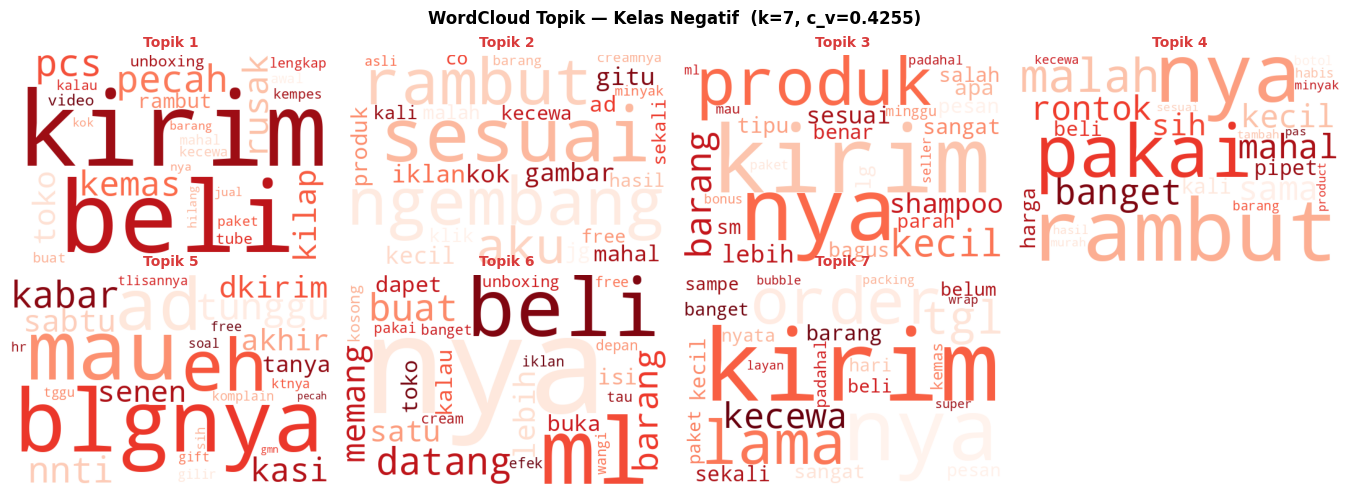

In [ ]:
# ===== 4.2d — WordCloud topik per kelas sentimen =====
from wordcloud import WordCloud
cmap = {'Positif': 'Greens', 'Netral': 'YlOrBr', 'Negatif': 'Reds'}

for kelas, v in HASIL_LDA.items():
    k = v['k_opt']
    kol = min(k, 4); bar = int(np.ceil(k / kol))
    fig, axes = plt.subplots(bar, kol, figsize=(3.4*kol, 2.5*bar))
    axes = np.atleast_1d(axes).ravel()
    for t in range(k):
        bobot = dict(v['lda'].show_topic(t, topn=25))
        wc = WordCloud(width=520, height=340, background_color='white',
                       colormap=cmap[kelas]).generate_from_frequencies(bobot)
        axes[t].imshow(wc); axes[t].axis('off')
        axes[t].set_title(f'Topik {t+1}', fontsize=10, fontweight='bold', color=COL[kelas])
    for t in range(k, len(axes)): axes[t].axis('off')
    fig.suptitle(f'WordCloud Topik — Kelas {kelas}  (k={k}, c_v={v["cv_opt"]:.4f})',
                 fontweight='bold', fontsize=12)
    plt.tight_layout()
    plt.savefig(FOLDER + f'fig_wordcloud_{kelas.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## 5. Evaluation — Sub Bab 3.6 / 4.6

Empat aspek evaluasi: akurasi klasifikasi, kualitas topik, fungsionalitas sistem,
dan analisis data pendukung.

### 5.1 Pengujian Akurasi Klasifikasi — Sub Bab 4.6.1

In [ ]:
# ===== 5.1a [SS] — Classification report mentah =====
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, precision_recall_fscore_support)

pred_out  = trainer.predict(ds_test)
y_true_id = pred_out.label_ids
y_pred_id = pred_out.predictions.argmax(-1)
y_true = [id2label[i] for i in y_true_id]
y_pred = [id2label[i] for i in y_pred_id]

acc = accuracy_score(y_true, y_pred)
mf1 = f1_score(y_true, y_pred, average='macro')

print("=== HASIL PENGUJIAN PADA DATA UJI ===")
print(f"Jumlah data uji : {len(y_true)}")
print(f"Accuracy        : {acc:.4f}  ({acc*100:.2f}%)")
print(f"Macro-F1        : {mf1:.4f}\n")
print(classification_report(y_true, y_pred, labels=ORDER, digits=4, zero_division=0))

p, r, f1c, sup = precision_recall_fscore_support(y_true, y_pred, labels=ORDER, zero_division=0)
tabel_klas = pd.DataFrame({'Kelas': ORDER, 'Precision': p.round(4),
                           'Recall': r.round(4), 'F1-Score': f1c.round(4), 'Support': sup})
tabel_klas.loc[len(tabel_klas)] = ['Macro Avg', round(p.mean(), 4), round(r.mean(), 4),
                                   round(mf1, 4), sup.sum()]
print("=== TABEL HASIL KLASIFIKASI (untuk Tabel 4.7) ===")
display(tabel_klas)
tabel_klas.to_csv(FOLDER + 'tabel_klasifikasi.csv', index=False)

=== HASIL PENGUJIAN PADA DATA UJI ===
Jumlah data uji : 1075
Accuracy        : 0.9479  (94.79%)
Macro-F1        : 0.6021

              precision    recall  f1-score   support

     Positif     0.9708    0.9823    0.9765      1015
      Netral     0.3077    0.2581    0.2807        31
     Negatif     0.6364    0.4828    0.5490        29

    accuracy                         0.9479      1075
   macro avg     0.6383    0.5744    0.6021      1075
weighted avg     0.9426    0.9479    0.9449      1075

=== TABEL HASIL KLASIFIKASI (untuk Tabel 4.7) ===


,Kelas,Precision,Recall,F1-Score,Support
0,Positif,0.9708,0.9823,0.9765,1015
1,Netral,0.3077,0.2581,0.2807,31
2,Negatif,0.6364,0.4828,0.5490,29
3,Macro Avg,0.6383,0.5744,0.6021,1075


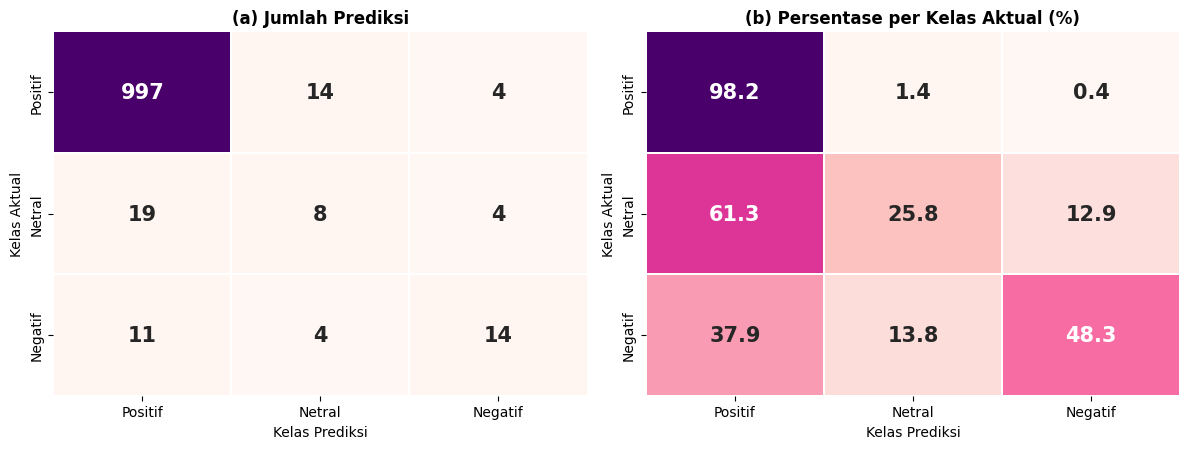

,Prediksi Positif,Prediksi Netral,Prediksi Negatif
Aktual Positif,997,14,4
Aktual Netral,19,8,4
Aktual Negatif,11,4,14



=== ARAH KESALAHAN TERBESAR ===
  Positif  salah diprediksi Netral  :   14 ulasan (1.4% dari kelas Positif)
  Positif  salah diprediksi Negatif :    4 ulasan (0.4% dari kelas Positif)
  Netral   salah diprediksi Positif :   19 ulasan (61.3% dari kelas Netral)
  Netral   salah diprediksi Negatif :    4 ulasan (12.9% dari kelas Netral)
  Negatif  salah diprediksi Positif :   11 ulasan (37.9% dari kelas Negatif)
  Negatif  salah diprediksi Netral  :    4 ulasan (13.8% dari kelas Negatif)


In [ ]:
# ===== 5.1b — Confusion Matrix =====
import seaborn as sns

cm = confusion_matrix(y_true, y_pred, labels=ORDER)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu', cbar=False, ax=ax[0],
            xticklabels=ORDER, yticklabels=ORDER, linewidths=1.4, linecolor='white',
            annot_kws={'fontsize': 15, 'fontweight': 'bold'})
ax[0].set_title('(a) Jumlah Prediksi', fontweight='bold')
ax[0].set_xlabel('Kelas Prediksi'); ax[0].set_ylabel('Kelas Aktual')

sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='RdPu', cbar=False, ax=ax[1],
            xticklabels=ORDER, yticklabels=ORDER, linewidths=1.4, linecolor='white',
            annot_kws={'fontsize': 15, 'fontweight': 'bold'})
ax[1].set_title('(b) Persentase per Kelas Aktual (%)', fontweight='bold')
ax[1].set_xlabel('Kelas Prediksi'); ax[1].set_ylabel('Kelas Aktual')

plt.tight_layout()
plt.savefig(FOLDER + 'fig_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tabel_cm = pd.DataFrame(cm, index=[f'Aktual {c}' for c in ORDER],
                        columns=[f'Prediksi {c}' for c in ORDER])
display(tabel_cm)
tabel_cm.to_csv(FOLDER + 'tabel_confusion_matrix.csv')

print("\n=== ARAH KESALAHAN TERBESAR ===")
for i, akt in enumerate(ORDER):
    for j, prd in enumerate(ORDER):
        if i != j and cm[i][j] > 0:
            print(f"  {akt:8} salah diprediksi {prd:8}: {cm[i][j]:>4} ulasan "
                  f"({cm[i][j]/cm[i].sum()*100:.1f}% dari kelas {akt})")

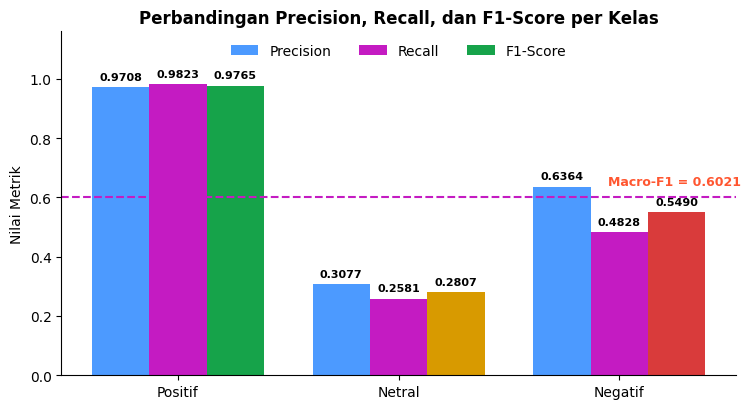

In [ ]:
# ===== 5.1c — Grafik metrik per kelas =====
x = np.arange(len(ORDER)); w = 0.26
fig, ax = plt.subplots(figsize=(7.6, 4.2))
ax.bar(x - w, p,   w, label='Precision', color='#4C9AFF')
ax.bar(x,     r,   w, label='Recall',    color='#C41BC2')
ax.bar(x + w, f1c, w, label='F1-Score',  color=[COL[c] for c in ORDER])

for i in range(len(ORDER)):
    for off, v in [(-w, p[i]), (0, r[i]), (w, f1c[i])]:
        ax.text(x[i] + off, v + 0.025, f'{v:.4f}', ha='center', fontsize=8, fontweight='bold')

ax.axhline(mf1, color='#C41BC2', ls='--', lw=1.5)
ax.text(len(ORDER) - 0.45, mf1 + 0.04, f'Macro-F1 = {mf1:.4f}',
        ha='right', color='#FF5630', fontweight='bold', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(ORDER); ax.set_ylim(0, 1.16)
ax.set_ylabel('Nilai Metrik')
ax.set_title('Perbandingan Precision, Recall, dan F1-Score per Kelas', fontweight='bold')
ax.legend(ncol=3, frameon=False, loc='upper center')
for s in ['top', 'right']: ax.spines[s].set_visible(False)
plt.tight_layout(); plt.savefig(FOLDER + 'fig_metrik_per_kelas.png', dpi=150, bbox_inches='tight')
plt.show()

=== PERBANDINGAN DENGAN MODEL BASELINE ===


,Model,Accuracy,Macro-F1
0,Baseline (selalu Positif),0.9442,0.3238
1,Naive Bayes,0.9442,0.3238
2,SVM (LinearSVC),0.9507,0.6118
3,Logistic Regression,0.9200,0.5845
4,IndoBERT (penelitian ini),0.9479,0.6021


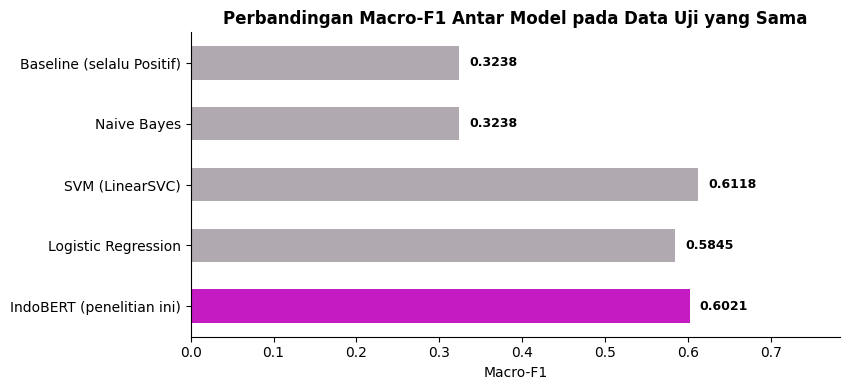

Catatan: laporkan hasil apa adanya. Bila baseline unggul pada kelas tertentu,
jelaskan penyebabnya (jumlah sampel minoritas sangat kecil).


In [ ]:
# ===== 5.1d — Perbandingan dengan model baseline =====
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression

Xtr_txt = train_df[TEXT].astype(str).values
Xte_txt = test_df[TEXT].astype(str).values
ytr = train_df['label'].values
yte = test_df['label'].values

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
Xtr = tfidf.fit_transform(Xtr_txt)
Xte = tfidf.transform(Xte_txt)

hasil = []
mayoritas = pd.Series(ytr).value_counts().idxmax()
pred_naif = [mayoritas] * len(yte)
hasil.append([f'Baseline (selalu {mayoritas})',
              accuracy_score(yte, pred_naif),
              f1_score(yte, pred_naif, average='macro', zero_division=0)])

for nama, m in [('Naive Bayes', MultinomialNB()),
                ('SVM (LinearSVC)', LinearSVC(class_weight='balanced', max_iter=5000)),
                ('Logistic Regression', LogisticRegression(class_weight='balanced', max_iter=2000))]:
    m.fit(Xtr, ytr); pr = m.predict(Xte)
    hasil.append([nama, accuracy_score(yte, pr),
                  f1_score(yte, pr, average='macro', zero_division=0)])

hasil.append(['IndoBERT (penelitian ini)', acc, mf1])

tab = pd.DataFrame(hasil, columns=['Model', 'Accuracy', 'Macro-F1'])
tab[['Accuracy', 'Macro-F1']] = tab[['Accuracy', 'Macro-F1']].round(4)
print("=== PERBANDINGAN DENGAN MODEL BASELINE ===")
display(tab)
tab.to_csv(FOLDER + 'tabel_perbandingan_baseline.csv', index=False)

fig, ax = plt.subplots(figsize=(8.6, 4))
warna = ['#B0AAB0'] * (len(tab) - 1) + ['#C41BC2']
b = ax.barh(tab['Model'], tab['Macro-F1'], color=warna, height=0.55)
for bb, v in zip(b, tab['Macro-F1']):
    ax.text(v + 0.012, bb.get_y() + bb.get_height()/2, f'{v:.4f}',
            va='center', fontsize=9, fontweight='bold')
ax.set_xlabel('Macro-F1'); ax.set_xlim(0, tab['Macro-F1'].max() * 1.28); ax.invert_yaxis()
ax.set_title('Perbandingan Macro-F1 Antar Model pada Data Uji yang Sama', fontweight='bold')
for s in ['top', 'right']: ax.spines[s].set_visible(False)
plt.tight_layout(); plt.savefig(FOLDER + 'fig_perbandingan_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

print("Catatan: laporkan hasil apa adanya. Bila baseline unggul pada kelas tertentu,")
print("jelaskan penyebabnya (jumlah sampel minoritas sangat kecil).")

In [ ]:
# ===== 5.1e [SS] — Analisis kesalahan klasifikasi =====
salah = pd.DataFrame({'Ulasan': test_df[TEXT].astype(str).values,
                      'Rating': test_df['rating'].values,
                      'Aktual': y_true, 'Prediksi': y_pred})
salah = salah[salah.Aktual != salah.Prediksi]

print(f"Total kesalahan : {len(salah)} dari {len(y_true)} data uji "
      f"({len(salah)/len(y_true)*100:.2f}%)\n")
print("=== ARAH KESALAHAN ===")
print(salah.groupby(['Aktual', 'Prediksi']).size().to_string())

print("\n=== CONTOH KESALAHAN PER KELAS ===")
contoh = salah.groupby('Aktual', group_keys=False).head(2).copy()
contoh['Ulasan'] = contoh['Ulasan'].str.slice(0, 80)
display(contoh)
contoh.to_csv(FOLDER + 'tabel_error_analysis.csv', index=False)

Total kesalahan : 56 dari 1075 data uji (5.21%)

=== ARAH KESALAHAN ===
Aktual   Prediksi
Negatif  Netral       4
         Positif     11
Netral   Negatif      4
         Positif     19
Positif  Negatif      4
         Netral      14

=== CONTOH KESALAHAN PER KELAS ===


,Ulasan,Rating,Aktual,Prediksi
10,absolute wastage of money,1.0,Negatif,Positif
16,pipetnya pecah mohon lbh diperhatikan lagi mengingat har...,4.0,Positif,Netral
19,dikit banget tolong dah meleleh juga,3.0,Netral,Positif
20,review jujur buat aku ini overrated overpriced juga kupi...,3.0,Netral,Positif
59,iya bagus,2.0,Negatif,Positif
95,tidak dapet free nya,5.0,Positif,Netral


### 5.2 Evaluasi Topic Modeling — Sub Bab 4.6.2

In [ ]:
# ===== 5.2 — Rekapitulasi kualitas topik =====
rekap = pd.DataFrame([{
    'Kelas': k,
    'Jumlah Dokumen': v['n_docs'],
    'k Optimal': v['k_opt'],
    'Coherence (c_v)': round(v['cv_opt'], 4),
    'Rentang c_v yang diuji': f"{min(v['coherence'].values()):.4f} - {max(v['coherence'].values()):.4f}",
} for k, v in HASIL_LDA.items()])
print("=== EVALUASI KUALITAS TOPIK ===")
display(rekap)
rekap.to_csv(FOLDER + 'tabel_evaluasi_topik.csv', index=False)

print("\nInterpretasi: nilai coherence cenderung menurun seiring mengecilnya jumlah")
print("dokumen per kelas. Meskipun demikian, seluruh topik tetap dapat diinterpretasikan")
print("dan telah divalidasi secara manual terhadap konteks produk SH-RD: Protein Cream.")

=== EVALUASI KUALITAS TOPIK ===


,Kelas,Jumlah Dokumen,k Optimal,Coherence (c_v),Rentang c_v yang diuji
0,Positif,5065,4,0.5608,0.5033 - 0.5608
1,Netral,152,2,0.4212,0.3515 - 0.4212
2,Negatif,136,7,0.4255,0.2903 - 0.4255



Interpretasi: nilai coherence cenderung menurun seiring mengecilnya jumlah
dokumen per kelas. Meskipun demikian, seluruh topik tetap dapat diinterpretasikan
dan telah divalidasi secara manual terhadap konteks produk SH-RD: Protein Cream.


### 5.3 Blackbox Testing — Sub Bab 4.6.3

Pengujian fungsionalitas dilakukan secara manual terhadap *dashboard* yang telah berjalan
(Bagian 6). Sel di bawah hanya merekap hasilnya menjadi tabel dan gambar untuk naskah.

In [ ]:
# ===== 5.3 — Rekap hasil blackbox testing =====
skenario = [
    ('BB-01', 'Membuka halaman utama dashboard',            'Dashboard tampil tanpa galat'),
    ('BB-02', 'Navigasi ke halaman Ringkasan',              'Halaman Ringkasan tampil'),
    ('BB-03', 'Navigasi ke halaman Analisis Sentimen',      'Halaman Analisis Sentimen tampil'),
    ('BB-04', 'Navigasi ke halaman Topic Modeling',         'Halaman Topic Modeling tampil'),
    ('BB-05', 'Navigasi ke halaman Tren Ulasan',            'Halaman Tren Ulasan tampil'),
    ('BB-06', 'Navigasi ke halaman Insight & Rekomendasi',  'Halaman Insight tampil'),
    ('BB-07', 'Filter platform Shopee',                     'Data tersaring hanya Shopee'),
    ('BB-08', 'Filter platform Tokopedia',                  'Data tersaring hanya Tokopedia'),
    ('BB-09', 'Filter rentang tanggal',                     'Data tersaring sesuai rentang'),
    ('BB-10', 'Filter kategori sentimen',                   'Data tersaring sesuai kelas'),
    ('BB-11', 'Membuka pop-up contoh ulasan pada topik',    'Pop-up ulasan asli tampil'),
    ('BB-12', 'Mengunduh data ulasan (.csv)',               'Berkas terunduh sesuai filter'),
    ('BB-13', 'Kondisi filter menghasilkan data kosong',    'Pesan data kosong tampil, tanpa galat'),
]

# Ubah menjadi 'Gagal' bila ada skenario yang tidak lolos saat pengujian
STATUS = ['Berhasil'] * len(skenario)

tabel_bb = pd.DataFrame(skenario, columns=['Kode', 'Skenario Pengujian', 'Hasil yang Diharapkan'])
tabel_bb['Status'] = STATUS
display(tabel_bb)
tabel_bb.to_csv(FOLDER + 'tabel_blackbox.csv', index=False)

n_ok = (tabel_bb['Status'] == 'Berhasil').sum()
print(f"\nSkenario diuji     : {len(tabel_bb)}")
print(f"Berhasil           : {n_ok}")
print(f"Gagal              : {len(tabel_bb) - n_ok}")
print(f"Tingkat keberhasilan: {n_ok/len(tabel_bb)*100:.0f}%")

,Kode,Skenario Pengujian,Hasil yang Diharapkan,Status
0,BB-01,Membuka halaman utama dashboard,Dashboard tampil tanpa galat,Berhasil
1,BB-02,Navigasi ke halaman Ringkasan,Halaman Ringkasan tampil,Berhasil
2,BB-03,Navigasi ke halaman Analisis Sentimen,Halaman Analisis Sentimen tampil,Berhasil
3,BB-04,Navigasi ke halaman Topic Modeling,Halaman Topic Modeling tampil,Berhasil
4,BB-05,Navigasi ke halaman Tren Ulasan,Halaman Tren Ulasan tampil,Berhasil
5,BB-06,Navigasi ke halaman Insight & Rekomendasi,Halaman Insight tampil,Berhasil
6,BB-07,Filter platform Shopee,Data tersaring hanya Shopee,Berhasil
7,BB-08,Filter platform Tokopedia,Data tersaring hanya Tokopedia,Berhasil
8,BB-09,Filter rentang tanggal,Data tersaring sesuai rentang,Berhasil
9,BB-10,Filter kategori sentimen,Data tersaring sesuai kelas,Berhasil



Skenario diuji     : 13
Berhasil           : 13
Gagal              : 0
Tingkat keberhasilan: 100%


### 5.4 Analisis Kepercayaan Pengguna — Sub Bab 4.6.4

In [ ]:
# ===== 5.4 — Analisis kuesioner (data pendukung) =====
# Letakkan hasil unduhan Google Form sebagai 'kuesioner.csv' di FOLDER.
path_kues = FOLDER + 'kuesioner.csv'

if os.path.exists(path_kues):
    kues = pd.read_csv(path_kues)
    print("Jumlah responden:", len(kues))
    kolom_skala = [c for c in kues.columns
                   if pd.api.types.is_numeric_dtype(kues[c]) and kues[c].max() <= 5]
    if kolom_skala:
        rata = kues[kolom_skala].mean().round(2)
        rekap_k = pd.DataFrame({'Pernyataan': rata.index, 'Rata-rata (skala 1-5)': rata.values})
        display(rekap_k)
        print(f"\nSkor rata-rata keseluruhan: {rata.mean():.2f} dari 5")
        rekap_k.to_csv(FOLDER + 'tabel_kuesioner.csv', index=False)
    else:
        print("Kolom skala tidak terdeteksi otomatis. Sesuaikan nama kolom secara manual.")
else:
    print("Berkas 'kuesioner.csv' belum ada di", FOLDER)
    print("Unduh tanggapan Google Form sebagai CSV, ganti namanya, lalu jalankan ulang sel ini.")

Jumlah responden: 42


,Pernyataan,Rata-rata (skala 1-5)
0,"Jika ya, ulasan/rating memengaruhi keputusan Anda membel...",3.75



Skor rata-rata keseluruhan: 3.75 dari 5


---
## 6. Deployment — Sub Bab 3.7 / 4.7

Implementasi *dashboard monitoring* berbasis Streamlit. Bagian ini berasal dari
`Dashboard.ipynb` dan kini memakai `FOLDER` yang sama dengan seluruh notebook.

In [ ]:
# ===== 6.1 [SS] — Verifikasi berkas keluaran penelitian =====
berkas = [
    ('reviews_GABUNGAN.csv',  'Hasil penggabungan dua marketplace'),
    ('reviews_CLEAN.csv',     'Hasil cleaning'),
    ('reviews_STEMMING.csv',  'Hasil enam tahap pre-processing'),
    ('hasil_labeling.csv',    'Hasil pelabelan berbasis rating'),
    ('data_train.csv',        'Data latih (80%)'),
    ('data_test.csv',         'Data uji (20%)'),
    ('class_weights.npy',     'Bobot kelas'),
    ('hasil_prediksi.csv',    'Hasil prediksi — DIBACA OLEH DASHBOARD'),
]

print(f"{'Berkas':<26}{'Ukuran (KB)':>13}{'Baris':>9}  Keterangan")
print("-" * 92)
for nama, ket in berkas:
    p = FOLDER + nama
    if os.path.exists(p):
        kb = os.path.getsize(p) / 1024
        n  = len(pd.read_csv(p)) if nama.endswith('.csv') else '-'
        print(f"{nama:<26}{kb:>13.1f}{str(n):>9}  {ket}")
    else:
        print(f"{nama:<26}{'TIDAK DITEMUKAN':>22}  {ket}")

print("\nKolom pada hasil_prediksi.csv:")
print(pd.read_csv(FOLDER + 'hasil_prediksi.csv').columns.tolist())

Berkas                      Ukuran (KB)    Baris  Keterangan
--------------------------------------------------------------------------------------------
reviews_GABUNGAN.csv              932.6     5753  Hasil penggabungan dua marketplace
reviews_CLEAN.csv                1542.8     5373  Hasil cleaning
reviews_STEMMING.csv             5402.5     5373  Hasil enam tahap pre-processing
hasil_labeling.csv               5444.3     5373  Hasil pelabelan berbasis rating
data_train.csv                   4393.5     4298  Data latih (80%)
data_test.csv                    1061.4     1075  Data uji (20%)
class_weights.npy                   0.1        -  Bobot kelas
hasil_prediksi.csv               5486.2     5373  Hasil prediksi — DIBACA OLEH DASHBOARD

Kolom pada hasil_prediksi.csv:
['platform', 'username', 'rating', 'tanggal', 'content', 'cleaning', 'case_folding', 'normalization', 'tokenization', 'stopword_removal', 'stemming', 'label', 'sentimen_pred']


In [ ]:
# ===== 6.2 — Instalasi Streamlit dan cloudflared =====
!pip install -q streamlit plotly wordcloud gensim
!wget -q -c https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared
print("Instalasi selesai.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 89.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 107.2 MB/s eta 0:00:00
Instalasi selesai.


In [ ]:
# ===== 6.3 — Menyiapkan app.py dan tema Streamlit =====
import shutil

os.makedirs('.streamlit', exist_ok=True)
with open('.streamlit/config.toml', 'w') as f:
    f.write("""[theme]
primaryColor = "#C41BC2"
backgroundColor = "#FFFFFF"
secondaryBackgroundColor = "#FBEAF8"
textColor = "#241E24"
font = "sans serif"

[server]
headless = true
""")

sumber = FOLDER + 'app.py'
if os.path.exists(sumber):
    shutil.copy(sumber, '/content/app.py')
    print("app.py disalin dari Drive. Ukuran:", round(os.path.getsize('/content/app.py')/1024, 1), "KB")
else:
    print("PERINGATAN: app.py tidak ditemukan di", sumber)
    print("Unggah app.py ke folder SKRIPSI di Google Drive, lalu jalankan ulang sel ini.")

# Pastikan dashboard membaca berkas dari FOLDER yang sama dengan notebook ini
if os.path.exists('/content/app.py'):
    kode = open('/content/app.py').read()
    kode = kode.replace('/content/drive/MyDrive/skripsi/', FOLDER)
    kode = kode.replace('/content/drive/MyDrive/SKRIPSI/', FOLDER)
    open('/content/app.py', 'w').write(kode)
    print("Jalur berkas pada app.py diselaraskan ke:", FOLDER)

app.py disalin dari Drive. Ukuran: 33.9 KB
Jalur berkas pada app.py diselaraskan ke: /content/drive/MyDrive/SKRIPSI/


In [ ]:
# ===== 6.4 — Menjalankan dashboard + tunnel publik =====
import subprocess

subprocess.Popen(['python', '-m', 'streamlit', 'run', 'app.py',
                  '--server.port', '8501', '--server.headless', 'true'])
time.sleep(12)
print(">> Tunggu tautan 'https://xxxx.trycloudflare.com' muncul di bawah, lalu klik.\n")
!/content/cloudflared tunnel --url http://localhost:8501

>> Tunggu tautan 'https://xxxx.trycloudflare.com' muncul di bawah, lalu klik.

2026-08-16T09:08:09Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-08-16T09:08:09Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-08-16T09:08:13Z INF +--------------------------------------------------------------------------------------------+
2026-08-16T09:08:13Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
20

---
## 7. Rekapitulasi Keluaran

Sel terakhir merangkum seluruh berkas gambar dan tabel yang dihasilkan notebook ini,
beserta pemetaannya ke sub bab pada naskah skripsi.

In [ ]:
# ===== 7 — Daftar keluaran dan pemetaannya ke naskah =====
keluaran = [
    ('fig_data_understanding.png',     'Gambar', '4.1',   'Kondisi awal data: platform & rating'),
    ('tabel_jejak_preprocessing.csv',  'Tabel',  '4.2',   'Jejak satu ulasan melalui 6 tahap'),
    ('fig_distribusi_sentimen.png',    'Gambar', '4.3.1', 'Distribusi & proporsi kelas sentimen'),
    ('fig_wordcloud_semua.png',        'Gambar', '4.3.1', 'WordCloud seluruh ulasan'),
    ('fig_class_weight.png',           'Gambar', '4.4',   'Bobot kelas (class weight)'),
    ('tabel_riwayat_epoch.csv',        'Tabel',  '4.5.1', 'Riwayat pelatihan per epoch'),
    ('fig_training_history.png',       'Gambar', '4.5.1', 'Grafik training history'),
    ('fig_coherence_vs_k.png',         'Gambar', '4.5.2', 'Pemilihan k optimal per kelas'),
    ('fig_coherence_perkelas.png',     'Gambar', '4.5.2', 'Perbandingan coherence antar kelas'),
    ('tabel_topik_lda.csv',            'Tabel',  '4.5.2', 'Kata kunci per topik'),
    ('fig_wordcloud_positif.png',      'Gambar', '4.5.2', 'WordCloud topik kelas Positif'),
    ('fig_wordcloud_netral.png',       'Gambar', '4.5.2', 'WordCloud topik kelas Netral'),
    ('fig_wordcloud_negatif.png',      'Gambar', '4.5.2', 'WordCloud topik kelas Negatif'),
    ('tabel_klasifikasi.csv',          'Tabel',  '4.6.1', 'Hasil klasifikasi per kelas'),
    ('fig_confusion_matrix.png',       'Gambar', '4.6.1', 'Confusion matrix'),
    ('tabel_confusion_matrix.csv',     'Tabel',  '4.6.1', 'Confusion matrix (angka)'),
    ('fig_metrik_per_kelas.png',       'Gambar', '4.6.1', 'Precision/Recall/F1 per kelas'),
    ('tabel_perbandingan_baseline.csv','Tabel',  '4.6.1', 'Perbandingan dengan baseline'),
    ('fig_perbandingan_baseline.png',  'Gambar', '4.6.1', 'Grafik perbandingan baseline'),
    ('tabel_error_analysis.csv',       'Tabel',  '4.6.1', 'Contoh kesalahan klasifikasi'),
    ('tabel_koptimal_coherence.csv',   'Tabel',  '4.6.2', 'k optimal & coherence per kelas'),
    ('tabel_evaluasi_topik.csv',       'Tabel',  '4.6.2', 'Rekap evaluasi kualitas topik'),
    ('tabel_blackbox.csv',             'Tabel',  '4.6.3', 'Hasil blackbox testing'),
    ('tabel_kuesioner.csv',            'Tabel',  '4.6.4', 'Rekap kuesioner kepercayaan'),
]

baris = []
for nama, jenis, sub, ket in keluaran:
    ada = os.path.exists(FOLDER + nama)
    baris.append({'Berkas': nama, 'Jenis': jenis, 'Sub Bab': sub,
                  'Keterangan': ket, 'Status': 'Tersedia' if ada else 'Belum dibuat'})

rekap_out = pd.DataFrame(baris)
display(rekap_out)
rekap_out.to_csv(FOLDER + 'REKAP_KELUARAN.csv', index=False)

n_ada = (rekap_out['Status'] == 'Tersedia').sum()
print(f"\nKeluaran tersedia: {n_ada} dari {len(rekap_out)}")
print("Rekap disimpan sebagai REKAP_KELUARAN.csv")

print("\n" + "="*72)
print("SEL YANG PERLU DI-SCREENSHOT SEBAGAI BUKTI KEASLIAN [SS]")
print("="*72)
for s in ["0.3  Bukti lingkungan eksekusi",
          "2.2  Profil data mentah",
          "3.1  Log pembersihan data",
          "3.7  Jejak enam tahap pre-processing",
          "3.10 Pembagian data & class weight",
          "4.1c Proses fine-tuning IndoBERT  <-- PALING PENTING",
          "4.2c Keluaran mentah topik LDA",
          "5.1a Classification report",
          "5.1e Analisis kesalahan klasifikasi",
          "6.1  Verifikasi berkas keluaran"]:
    print("  -", s)

,Berkas,Jenis,Sub Bab,Keterangan,Status
0,fig_data_understanding.png,Gambar,4.1,Kondisi awal data: platform & rating,Tersedia
1,tabel_jejak_preprocessing.csv,Tabel,4.2,Jejak satu ulasan melalui 6 tahap,Tersedia
2,fig_distribusi_sentimen.png,Gambar,4.3.1,Distribusi & proporsi kelas sentimen,Tersedia
3,fig_wordcloud_semua.png,Gambar,4.3.1,WordCloud seluruh ulasan,Tersedia
4,fig_class_weight.png,Gambar,4.4,Bobot kelas (class weight),Tersedia
5,tabel_riwayat_epoch.csv,Tabel,4.5.1,Riwayat pelatihan per epoch,Tersedia
6,fig_training_history.png,Gambar,4.5.1,Grafik training history,Tersedia
7,fig_coherence_vs_k.png,Gambar,4.5.2,Pemilihan k optimal per kelas,Tersedia
8,fig_coherence_perkelas.png,Gambar,4.5.2,Perbandingan coherence antar kelas,Tersedia
9,tabel_topik_lda.csv,Tabel,4.5.2,Kata kunci per topik,Tersedia



Keluaran tersedia: 24 dari 24
Rekap disimpan sebagai REKAP_KELUARAN.csv

SEL YANG PERLU DI-SCREENSHOT SEBAGAI BUKTI KEASLIAN [SS]
  - 0.3  Bukti lingkungan eksekusi
  - 2.2  Profil data mentah
  - 3.1  Log pembersihan data
  - 3.7  Jejak enam tahap pre-processing
  - 3.10 Pembagian data & class weight
  - 4.1c Proses fine-tuning IndoBERT  <-- PALING PENTING
  - 4.2c Keluaran mentah topik LDA
  - 5.1a Classification report
  - 5.1e Analisis kesalahan klasifikasi
  - 6.1  Verifikasi berkas keluaran
